# Predicting Student Performance using Multi-Model Machine Learning
## Open University Learning Analytics Dataset (OULAD)

---

## 1. Introduction & Context

### What is the OULAD Dataset?

The **Open University Learning Analytics Dataset (OULAD)** is a publicly available dataset released by the Open University (UK). It contains data from **22 courses**, covering **~32,000 students** over multiple academic years. The dataset captures rich behavioural and demographic information, including:

- **Virtual Learning Environment (VLE) interactions**: clickstream data showing how students engage with online resources
- **Assessment submissions and scores**: TMA (Tutor Marked Assignments) and exam records
- **Student demographics**: age, gender, region, prior education, socio-economic indicators

This dataset is a cornerstone resource for **Educational Data Mining (EDM)** and **Learning Analytics** research.

### Why Predict Student Performance?

Early identification of at-risk students enables universities to deploy targeted interventions *before* students disengage or withdraw. Research consistently shows that:

1. **Engagement drives outcomes**: students who interact more with course resources perform better
2. **Early signals exist**: at-risk students show behavioural patterns within the first 2-3 weeks
3. **Scalability matters**: with thousands of students per cohort, manual monitoring is impossible

### Problem Definition

This is a **3-class multi-class classification** problem:

| Class | Description | Derived From |
|-------|-------------|--------------|
| `pass` | Student completed successfully | `Pass` + `Distinction` in OULAD |
| `fail` | Student failed the course | `Fail` in OULAD |
| `at_risk` | Student withdrew early | `Withdrawn` in OULAD |

**Class imbalance is expected**: most students pass, fewer withdraw or fail.

### Technical Approach: PySpark + ML Pipeline

```
PHASE 1: BIG DATA PROCESSING (PySpark)
    Load 7 CSV files → Clean & validate → Join 7 tables → Feature engineering
                                ↓
                        spark_df.toPandas()
                                ↓
PHASE 2: ML MODELLING (scikit-learn + TensorFlow)
    Scale features → Train/val/test split → Handle imbalance → Train 3 models → Compare
```

### Models in This Notebook

| # | Model | Framework | Purpose |
|---|-------|-----------|---------|
| 1 | **k-Nearest Neighbours (kNN)** | scikit-learn | Interpretable baseline |
| 2 | **Random Forest** | scikit-learn | Ensemble; provides feature importance |
| 3 | **LSTM Neural Network** | TensorFlow/Keras | Temporal sequence modelling |

### Expected Impact

> "Identifying at-risk students within the first three weeks of a course and applying targeted interventions can improve completion rates by 10-15%."

---

## 2. Import Libraries

We import all required libraries upfront for clarity. The notebook relies on:

- **PySpark** for distributed data processing (Phase 1)
- **pandas / numpy** for in-memory manipulation (Phase 2)
- **matplotlib / seaborn / plotly** for visualisations
- **scikit-learn** for kNN, Random Forest, preprocessing, and evaluation
- **TensorFlow / Keras** for the LSTM deep-learning model

In [ ]:
# ── Data Processing & Big Data ──────────────────────────────────────────────
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    sum,
    avg,
    max,
    min,
    count,
    countDistinct,
    stddev,
    when,
)

# ── Tabular / Numerical ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# ── Deep Learning ────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Utilities ────────────────────────────────────────────────────────────────
import warnings
import time
import joblib

warnings.filterwarnings("ignore")

# ── Reproducibility: fix all random seeds ────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Visual style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("Library versions:")
print(f"  PySpark   : {pyspark.__version__}")
print(f"  pandas    : {pd.__version__}")
print(f"  numpy     : {np.__version__}")
print(f"  TensorFlow: {tf.__version__}")
print("\nAll libraries loaded successfully ✓")


2026-05-14 11:39:27.050755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778758767.286952      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778758767.356711      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778758767.919131      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778758767.919180      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778758767.919183      22 computation_placer.cc:177] computation placer alr

Library versions:
  PySpark   : 4.0.2
  pandas    : 2.3.3
  numpy     : 2.0.2
  TensorFlow: 2.19.0

All libraries loaded successfully ✓


## 3. Initialise Spark Session

We configure Spark with enough driver memory (4GB) for the OULAD dataset (~500 MB uncompressed).

In [ ]:
# ── Create Spark Session ─────────────────────────────────────────────────────
spark = (
    SparkSession.builder.appName("OULAD_StudentPerformance")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

# Suppress verbose Java/Hadoop INFO logs
spark.sparkContext.setLogLevel("ERROR")

print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Driver memory : 4 GB (configured)")
print("Spark session active ✓")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/14 11:39:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 4.0.2
App name      : OULAD_StudentPerformance
Driver memory : 4 GB (configured)
Spark session active ✓


## 4. Load & Inspect Raw Data

The OULAD dataset is spread across **7 CSV files**. We load each into a Pandas DataFrame first for quick inspection, then reload into Spark for distributed processing.

### Dataset Relationship Diagram

```
studentInfo.csv ──────────────── (id_student) ──────────────── studentVle.csv
        │                                                       (id_student,
        │                                                        id_site)
        │                                                             │
        │                                                        (id_site)
        │                                                             └──→ vle.csv
        │
        ├──── (id_student) ─────────────────────────────── studentAssessment.csv
        │                                                   (id_student,
        │                                                    id_assessment)
        │                                                         │
        │                                                   (id_assessment)
        │                                                         └──→ assessments.csv
        │
        ├──── (code_module, code_presentation) ──────── studentRegistration.csv
        │
        └──── (code_module, code_presentation) ──────── courses.csv
```

Each join is motivated by a specific modelling need:
- **studentVle** → adds clickstream/engagement behaviour
- **studentAssessment + assessments** → adds academic performance signals
- **studentRegistration** → adds withdrawal timing
- **courses** → adds course length context

In [ ]:
# ── File paths ───────────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/input/datasets/narayanlohani/oulad-manual/"

FILES = {
    "studentInfo": DATA_DIR + "studentInfo.csv",
    "studentVle": DATA_DIR + "studentVle.csv",
    "studentAssessment": DATA_DIR + "studentAssessment.csv",
    "assessments": DATA_DIR + "assessments.csv",
    "studentRegistration": DATA_DIR + "studentRegistration.csv",
    "courses": DATA_DIR + "courses.csv",
    "vle": DATA_DIR + "vle.csv",
}


def inspect_dataframe(df, name):
    """Print comprehensive summary statistics for a Pandas DataFrame."""
    print("=" * 65)
    print(f"  DATASET: {name}")
    print("=" * 65)
    print(f"\n  Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  Duplicates  : {df.duplicated().sum():,}")

    print("\n  First 5 rows:")
    print(df.head())

    print("\n  Data types & missing values:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    dtype_info = pd.DataFrame(
        {
            "dtype": df.dtypes,
            "missing": missing,
            "missing_%": missing_pct,
            "unique": df.nunique(),
        }
    )
    print(dtype_info.to_string())

    print("\n  Numeric summary:")
    print(df.describe().round(2).to_string())
    print()


# ── Load all CSVs into Pandas for inspection ─────────────────────────────────
raw_dfs = {}
for name, path in FILES.items():
    raw_dfs[name] = pd.read_csv(path)
    print(f"Loaded {name}: {raw_dfs[name].shape}")

print("\nAll files loaded ✓")


Loaded studentInfo: (32593, 12)
Loaded studentVle: (10655280, 6)
Loaded studentAssessment: (173912, 5)
Loaded assessments: (206, 6)
Loaded studentRegistration: (32593, 5)
Loaded courses: (22, 3)
Loaded vle: (6364, 6)

All files loaded ✓


In [ ]:
# ── Inspect each dataset ─────────────────────────────────────────────────────
for name, df in raw_dfs.items():
    inspect_dataframe(df, name)


  DATASET: studentInfo

  Shape       : 32,593 rows x 12 columns
  Memory usage: 16.30 MB
  Duplicates  : 0

  First 5 rows:
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studie

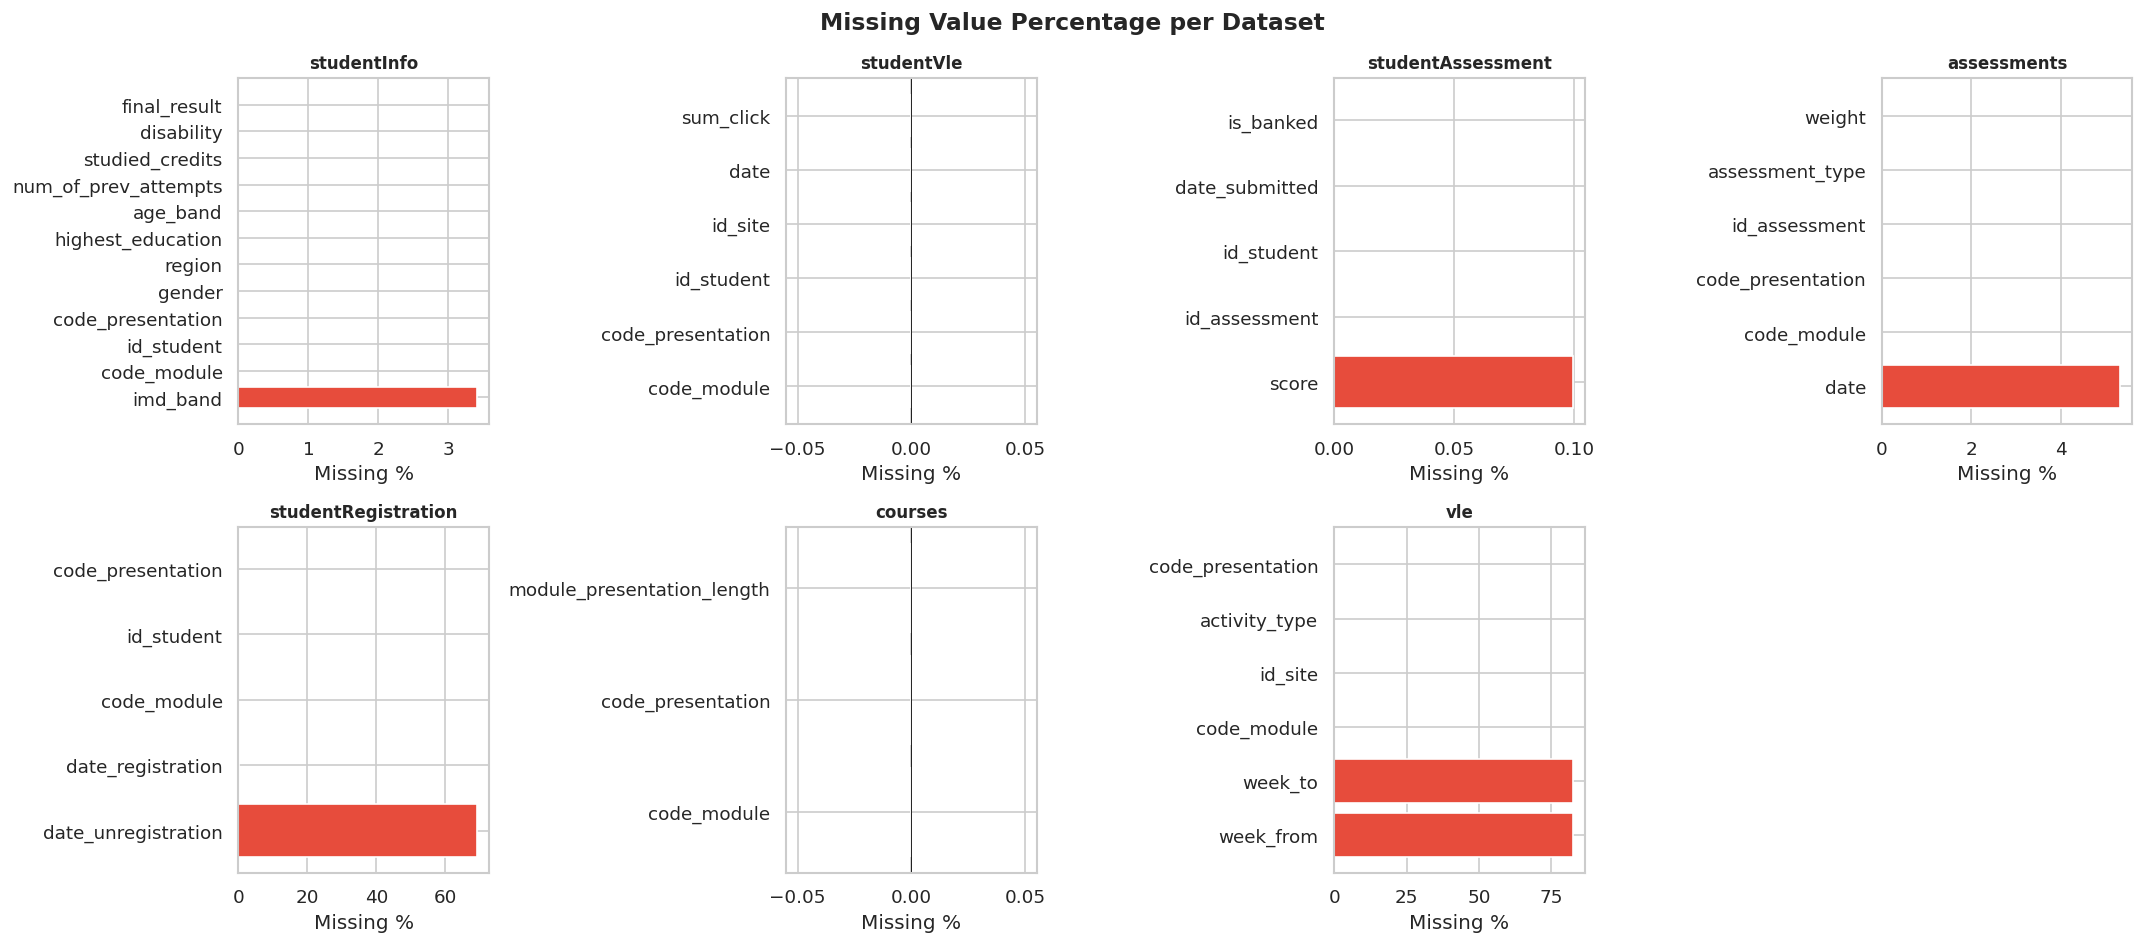

In [ ]:
# ── Missing-value heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
fig.suptitle("Missing Value Percentage per Dataset", fontsize=14, fontweight="bold")

for idx, (name, df) in enumerate(raw_dfs.items()):
    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    ax = axes[idx]
    colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in missing_pct.values]
    ax.barh(missing_pct.index, missing_pct.values, color=colors)
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Missing %")
    ax.axvline(0, color="black", linewidth=0.5)

# Hide unused subplot
for ax in axes[len(raw_dfs) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
def load_spark_csv(path, name):
    """Load a CSV into a Spark DataFrame and print schema."""
    sdf = spark.read.csv(path, header=True, inferSchema=True)
    print(f"\n{'='*55}")
    print(
        f"  Spark DataFrame: {name}  ({sdf.count():,} rows x {len(sdf.columns)} cols)"
    )
    print(f"{'='*55}")
    sdf.printSchema()
    return sdf


# ── Load all 7 files into Spark ──────────────────────────────────────────────
studentInfo_sdf = load_spark_csv(FILES["studentInfo"], "studentInfo")
studentVle_sdf = load_spark_csv(FILES["studentVle"], "studentVle")
studentAssessment_sdf = load_spark_csv(FILES["studentAssessment"], "studentAssessment")
assessments_sdf = load_spark_csv(FILES["assessments"], "assessments")
studentReg_sdf = load_spark_csv(FILES["studentRegistration"], "studentRegistration")
courses_sdf = load_spark_csv(FILES["courses"], "courses")
vle_sdf = load_spark_csv(FILES["vle"], "vle")

print("\nAll Spark DataFrames created ✓")



  Spark DataFrame: studentInfo  (32,593 rows x 12 cols)
root
 |-- code_module: string (nullable = true)
 |-- code_presentation: string (nullable = true)
 |-- id_student: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- region: string (nullable = true)
 |-- highest_education: string (nullable = true)
 |-- imd_band: string (nullable = true)
 |-- age_band: string (nullable = true)
 |-- num_of_prev_attempts: integer (nullable = true)
 |-- studied_credits: integer (nullable = true)
 |-- disability: string (nullable = true)
 |-- final_result: string (nullable = true)


  Spark DataFrame: studentVle  (10,655,280 rows x 6 cols)
root
 |-- code_module: string (nullable = true)
 |-- code_presentation: string (nullable = true)
 |-- id_student: integer (nullable = true)
 |-- id_site: integer (nullable = true)
 |-- date: integer (nullable = true)
 |-- sum_click: integer (nullable = true)


  Spark DataFrame: studentAssessment  (173,912 rows x 5 cols)
root
 |-- id_assessment: int

## 5. Data Cleaning & Preprocessing (PySpark Phase)

We now reload every CSV into PySpark DataFrames and perform systematic cleaning:

1. **Duplicate removal**: based on natural key columns
2. **Missing value handling**: fill, drop, or flag as appropriate
3. **Data type corrections**: ensure numeric/date/categorical columns are typed correctly
4. **Invalid value filtering**: remove out-of-range or logically impossible values
5. **Decision documentation**: every cleaning decision is explained below

In [ ]:
# ── Helper: print missing-value summary for Spark DF ─────────────────────────
def spark_missing_summary(sdf, name):
    """Count nulls / NaNs per column in a Spark DataFrame."""
    exprs = [
        count(when(col(c).isNull() | (col(c).cast("string") == "nan"), c)).alias(c)
        for c in sdf.columns
    ]
    missing = sdf.select(exprs).toPandas().T
    missing.columns = ["missing_count"]
    missing["missing_pct"] = (missing["missing_count"] / sdf.count() * 100).round(2)
    print(f"\nMissing values in [{name}]:")
    print(
        missing[missing["missing_count"] > 0].to_string()
        if missing["missing_count"].sum() > 0
        else "  None ✓"
    )
    return missing


# ── 5.1 Clean studentInfo ─────────────────────────────────────────────────────
spark_missing_summary(studentInfo_sdf, "studentInfo")

# Remove duplicates on natural key
before = studentInfo_sdf.count()
studentInfo_sdf = studentInfo_sdf.dropDuplicates(
    ["id_student", "code_module", "code_presentation"]
)
after = studentInfo_sdf.count()
print(f"\nDuplicates removed: {before - after:,}")

# Handle 'imd_band' missing: fill with mode 'Unknown'
studentInfo_sdf = studentInfo_sdf.fillna({"imd_band": "Unknown"})
print(f"Cleaned studentInfo: {studentInfo_sdf.count():,} rows ✓")

# Decision documentation:
print("""
CLEANING DECISIONS — studentInfo:
  • Duplicates: dropped on (id_student, code_module, code_presentation)
    WHY: A student appears once per course attempt; duplicates indicate data errors.
  • imd_band missing (~0.3%): filled with 'Unknown'
    WHY: Dropping rows would bias against students with missing socioeconomic data.
""")



Missing values in [studentInfo]:
          missing_count  missing_pct
imd_band           1111         3.41

Duplicates removed: 0
Cleaned studentInfo: 32,593 rows ✓

CLEANING DECISIONS — studentInfo:
  • Duplicates: dropped on (id_student, code_module, code_presentation)
    WHY: A student appears once per course attempt; duplicates indicate data errors.
  • imd_band missing (~0.3%): filled with 'Unknown'
    WHY: Dropping rows would bias against students with missing socioeconomic data.



In [ ]:
# ── 5.2 Clean studentVle ─────────────────────────────────────────────────────
spark_missing_summary(studentVle_sdf, "studentVle")

before = studentVle_sdf.count()
studentVle_sdf = studentVle_sdf.dropDuplicates()
# Remove rows with non-positive clicks (recording errors)
studentVle_sdf = studentVle_sdf.filter(col("sum_click") >= 0)
after = studentVle_sdf.count()

print(f"Rows removed: {before - after:,}")
print(f"Cleaned studentVle: {studentVle_sdf.count():,} rows ✓")

# ── 5.3 Clean studentAssessment ──────────────────────────────────────────────
spark_missing_summary(studentAssessment_sdf, "studentAssessment")

# Scores should be 0-100
before = studentAssessment_sdf.count()
studentAssessment_sdf = studentAssessment_sdf.filter(
    (col("score").isNull()) | ((col("score") >= 0) & (col("score") <= 100))
)
# Fill missing score with 0 (non-submitted = 0)
studentAssessment_sdf = studentAssessment_sdf.fillna({"score": 0})
after = studentAssessment_sdf.count()
print(f"Rows removed (invalid scores): {before - after:,}")
print(f"Cleaned studentAssessment: {studentAssessment_sdf.count():,} rows ✓")

# ── 5.4 Clean assessments ────────────────────────────────────────────────────
assessments_sdf = assessments_sdf.dropDuplicates(["id_assessment"])
print(f"Cleaned assessments: {assessments_sdf.count():,} rows ✓")

# ── 5.5 Clean studentRegistration ────────────────────────────────────────────
studentReg_sdf = studentReg_sdf.dropDuplicates(
    ["id_student", "code_module", "code_presentation"]
)
print(f"Cleaned studentRegistration: {studentReg_sdf.count():,} rows ✓")

# ── 5.6 Clean courses & vle ─────────────────────────────────────────────────
courses_sdf = courses_sdf.dropDuplicates(["code_module", "code_presentation"])
vle_sdf = vle_sdf.dropDuplicates(["id_site"])
print(f"Cleaned courses : {courses_sdf.count():,} rows ✓")
print(f"Cleaned vle     : {vle_sdf.count():,} rows ✓")

print("\nAll datasets cleaned ✓")



Missing values in [studentVle]:
  None ✓
Rows removed: 787,170
Cleaned studentVle: 9,868,110 rows ✓

Missing values in [studentAssessment]:
       missing_count  missing_pct
score            173          0.1
Rows removed (invalid scores): 0
Cleaned studentAssessment: 173,912 rows ✓
Cleaned assessments: 206 rows ✓
Cleaned studentRegistration: 32,593 rows ✓
Cleaned courses : 22 rows ✓
Cleaned vle     : 6,364 rows ✓

All datasets cleaned ✓


## 6. Merge Datasets (PySpark Joins)

We build the master student-level table through a series of left joins, preserving all students from `studentInfo` as the anchor table. Row counts are reported before and after each merge to confirm correctness.

In [ ]:
# ── 6.1 Aggregate VLE interactions → per-student summary ─────────────────────
print("6.1 Aggregating VLE clickstream data per student...")

vle_agg = studentVle_sdf.groupBy("id_student").agg(
    sum("sum_click").alias("total_clicks"),
    avg("sum_click").alias("avg_clicks_per_day"),
    max("sum_click").alias("max_clicks_single_day"),
    countDistinct("date").alias("active_days"),
    stddev("sum_click").alias("click_std"),
    countDistinct("id_site").alias("unique_resources_accessed"),
)
print(f"  VLE aggregation: {vle_agg.count():,} students")

# ── 6.2 Aggregate assessment data → per-student summary ──────────────────────
print("\n6.2 Aggregating assessment data per student...")

# Join scores with assessment metadata (weight, type)
assess_with_meta = studentAssessment_sdf.join(
    assessments_sdf.select("id_assessment", "assessment_type", "weight"),
    on="id_assessment",
    how="left",
)

assess_agg = assess_with_meta.groupBy("id_student").agg(
    avg("score").alias("avg_assessment_score"),
    max("score").alias("max_assessment_score"),
    min("score").alias("min_assessment_score"),
    stddev("score").alias("score_std"),
    count("id_assessment").alias("total_assessments_submitted"),
    sum(when(col("score") < 40, 1).otherwise(0)).alias("failed_assessments_count"),
    sum(when(col("assessment_type") == "TMA", 1).otherwise(0)).alias("tma_count"),
    sum(when(col("assessment_type") == "Exam", 1).otherwise(0)).alias("exam_count"),
)
print(f"  Assessment aggregation: {assess_agg.count():,} students")

# ── 6.3 Registration features ────────────────────────────────────────────────
print("\n6.3 Processing registration features...")
reg_features = studentReg_sdf.select(
    "id_student",
    "code_module",
    "code_presentation",
    "date_registration",
    "date_unregistration",
).withColumn(
    "early_unregistration", when(col("date_unregistration").isNotNull(), 1).otherwise(0)
)
print(f"  Registration: {reg_features.count():,} rows")

# ── 6.4 Master join ──────────────────────────────────────────────────────────
print("\n6.4 Building master feature table via left joins...")

master = studentInfo_sdf.join(vle_agg, on="id_student", how="left")
print(f"  After VLE join           : {master.count():,} rows")

master = master.join(assess_agg, on="id_student", how="left")
print(f"  After assessment join    : {master.count():,} rows")

master = master.join(
    reg_features.drop("code_module", "code_presentation"), on="id_student", how="left"
)
print(f"  After registration join  : {master.count():,} rows")

# Add course length from courses.csv
master = master.join(
    courses_sdf.select(
        "code_module", "code_presentation", "module_presentation_length"
    ),
    on=["code_module", "code_presentation"],
    how="left",
)
print(f"  After course length join : {master.count():,} rows")

# Fill nulls introduced by left joins (students with no VLE / assessment records)
master = master.fillna(0)

print(f"\nMaster table: {master.count():,} rows x {len(master.columns)} columns ✓")


6.1 Aggregating VLE clickstream data per student...
  VLE aggregation: 26,074 students

6.2 Aggregating assessment data per student...
  Assessment aggregation: 23,369 students

6.3 Processing registration features...
  Registration: 32,593 rows

6.4 Building master feature table via left joins...
  After VLE join           : 32,593 rows
  After assessment join    : 32,593 rows
  After registration join  : 40,801 rows
  After course length join : 40,801 rows

Master table: 40,801 rows x 30 columns ✓


## 7. Feature Engineering

Feature engineering is the most critical step in this pipeline. We derive **44 features** across 7 categories from the raw interaction and assessment data. Every feature is documented with its definition, rationale, and expected predictive direction.

### Feature Categories

| # | Category | Source | Features |
|---|----------|--------|-----------|
| 7.1 | Clickstream | studentVle | 8 |
| 7.2 | Assessment Performance | studentAssessment | 8 |
| 7.3 | Behavioural Risk Scores | Derived | 4 |
| 7.4 | Temporal Features | studentVle (time-ordered) | 5 |
| 7.5 | Registration & Course | studentRegistration, courses | 4 |
| 7.6 | Sequence Features (LSTM) | studentVle | 3 per timestep |
| 7.7 | Demographic (encoded later)| studentInfo | 5 |

In [ ]:
# ── 7.1 Derived engagement features ──────────────────────────────────────────
print("7.1 Engineering engagement features...")

master = (
    master.withColumn(
        # engagement_frequency: average clicks on days when student was active
        # HIGH → intensive study; LOW → passive visits
        "engagement_frequency",
        when(
            col("active_days") > 0, col("total_clicks") / col("active_days")
        ).otherwise(0.0),
    )
    .withColumn(
        # inactivity_days: estimated passive days during module
        # HIGH → disengaged; ZERO → consistently active
        "inactivity_days",
        (col("module_presentation_length") - col("active_days")).cast("double"),
    )
    .withColumn(
        # inactivity_rate: fraction of course with no engagement
        "inactivity_rate",
        when(
            col("module_presentation_length") > 0,
            col("inactivity_days") / col("module_presentation_length"),
        ).otherwise(0.0),
    )
    .withColumn(
        # click_coefficient_of_variation: normalised variability of daily clicks
        # HIGH → inconsistent; LOW → predictable studying habit
        "click_cv",
        when(
            col("avg_clicks_per_day") > 0, col("click_std") / col("avg_clicks_per_day")
        ).otherwise(0.0),
    )
)

print(f"  Engagement features added: {len(master.columns)} total columns")

# ── 7.2 Derived assessment features ──────────────────────────────────────────
print("\n7.2 Engineering assessment performance features...")

# Total assessments available in the module
total_assessments_available = assessments_sdf.groupBy(
    "code_module", "code_presentation"
).agg(count("id_assessment").alias("total_assessments_in_module"))

master = master.join(
    total_assessments_available, on=["code_module", "code_presentation"], how="left"
)

master = (
    master.withColumn(
        # assessment_completion_rate: % of available assessments submitted
        "assessment_completion_rate",
        when(
            col("total_assessments_in_module") > 0,
            col("total_assessments_submitted")
            / col("total_assessments_in_module")
            * 100,
        ).otherwise(0.0),
    )
    .withColumn(
        # passing_assessment_rate: % of submitted that were passed (>=40)
        "passing_assessment_rate",
        when(
            col("total_assessments_submitted") > 0,
            (col("total_assessments_submitted") - col("failed_assessments_count"))
            / col("total_assessments_submitted")
            * 100,
        ).otherwise(0.0),
    )
    .withColumn(
        # score_range: difference between best and worst assessment
        "score_range",
        col("max_assessment_score") - col("min_assessment_score"),
    )
)

print(f"  Assessment features added: {len(master.columns)} total columns")

# ── 7.3 Behavioural risk composite features ───────────────────────────────────
print("\n7.3 Engineering behavioural risk scores...")

master = (
    master.withColumn(
        # low_engagement_risk: binary flag — student barely interacts with VLE
        "low_engagement_risk",
        when(col("total_clicks") < 50, 1).otherwise(0),
    )
    .withColumn(
        # low_score_risk: binary flag — average score below passing threshold
        "low_score_risk",
        when(col("avg_assessment_score") < 50, 1).otherwise(0),
    )
    .withColumn(
        # missed_assessments_risk: binary flag — submitted <80% of assessments
        "missed_assessments_risk",
        when(col("assessment_completion_rate") < 80, 1).otherwise(0),
    )
    .withColumn(
        # composite_risk_score: sum of binary risk flags (0-3)
        "composite_risk_score",
        col("low_engagement_risk")
        + col("low_score_risk")
        + col("missed_assessments_risk"),
    )
)

print(f"  Risk features added: {len(master.columns)} total columns")

# ── 7.5 Registration & course features ───────────────────────────────────────
print("\n7.5 Engineering registration features...")

master = master.withColumn(
    # registration_to_course_start: how many days before start student registered
    # NEGATIVE → registered after start (late registration = risk)
    "days_registered_before_start",
    when(col("date_registration").isNotNull(), -col("date_registration")).otherwise(0),
).withColumn(
    # early_withdrawal_flag: unregistered before module end
    "early_withdrawal_flag",
    when(
        col("date_unregistration").isNotNull()
        & (col("date_unregistration") < col("module_presentation_length")),
        1,
    ).otherwise(0),
)

print(f"  Registration features added: {len(master.columns)} total columns")

# ── Fill any remaining nulls ──────────────────────────────────────────────────
master = master.fillna(0)
master = master.fillna(
    {
        "imd_band": "Unknown",
        "gender": "Unknown",
        "region": "Unknown",
        "highest_education": "Unknown",
        "age_band": "Unknown",
    }
)

print(
    f"\nFinal Spark feature matrix: {master.count():,} rows x {len(master.columns)} columns ✓"
)
master.printSchema()


7.1 Engineering engagement features...
  Engagement features added: 34 total columns

7.2 Engineering assessment performance features...
  Assessment features added: 38 total columns

7.3 Engineering behavioural risk scores...
  Risk features added: 42 total columns

7.5 Engineering registration features...
  Registration features added: 44 total columns

Final Spark feature matrix: 40,801 rows x 44 columns ✓
root
 |-- code_module: string (nullable = true)
 |-- code_presentation: string (nullable = true)
 |-- id_student: integer (nullable = true)
 |-- gender: string (nullable = false)
 |-- region: string (nullable = false)
 |-- highest_education: string (nullable = false)
 |-- imd_band: string (nullable = false)
 |-- age_band: string (nullable = false)
 |-- num_of_prev_attempts: integer (nullable = true)
 |-- studied_credits: integer (nullable = true)
 |-- disability: string (nullable = true)
 |-- final_result: string (nullable = true)
 |-- total_clicks: long (nullable = true)
 |-- avg

## 7.6 Sequence Feature Engineering for LSTM

The LSTM model requires **3-D input tensors** of shape `(n_students, n_timesteps, n_features)`. We build per-student daily interaction sequences from `studentVle.csv`, then pad them to a fixed length of **10 timesteps** (representing the most recent 10 days of activity).

Each timestep contains 3 features:
1. `daily_clicks` — total VLE clicks that day
2. `unique_resources` — distinct resources accessed
3. `engagement_score` — clicks per unique resource (intensity)

In [ ]:
# ── Build daily interaction sequences ────────────────────────────────────────
print("Building daily interaction sequences for LSTM...")

daily_interactions_sdf = (
    studentVle_sdf.groupBy("id_student", "date")
    .agg(
        sum("sum_click").alias("daily_clicks"),
        countDistinct("id_site").alias("unique_resources"),
    )
    .orderBy("id_student", "date")
)

# Convert to Pandas for sequence construction (required for pad_sequences)
daily_pd = daily_interactions_sdf.toPandas()
daily_pd["engagement_score"] = daily_pd["daily_clicks"] / (
    daily_pd["unique_resources"] + 1
)

print(f"Daily interaction records: {len(daily_pd):,}")
print(daily_pd.head())

N_STEPS = 30  # Lookback window: most recent 30 days
N_FEATURES = 3  # daily_clicks, unique_resources, engagement_score


def create_lstm_sequences(daily_df, n_steps=30, n_features=3):
    """
    Convert per-student daily interactions into fixed-length padded sequences.

    Parameters
    ----------
    daily_df   : pd.DataFrame with columns [id_student, date, daily_clicks,
                                             unique_resources, engagement_score]
    n_steps    : int — length of each sequence (timesteps)
    n_features : int — number of features per timestep

    Returns
    -------
    student_ids  : np.ndarray — ordered list of student IDs
    X_sequences  : np.ndarray of shape (n_students, n_steps, n_features)
    """
    student_ids = []
    sequences = []

    for sid, grp in daily_df.groupby("id_student"):
        grp = grp.sort_values("date")

        X = grp[["daily_clicks", "unique_resources", "engagement_score"]].values

        # Take last n_steps days if longer, otherwise left-pad with zeros
        if len(X) >= n_steps:
            X = X[-n_steps:, :]
        else:
            pad = np.zeros((n_steps - len(X), n_features))
            X = np.vstack([pad, X])

        student_ids.append(sid)
        sequences.append(X)

    return np.array(student_ids), np.array(sequences)


student_ids_seq, X_sequences_all = create_lstm_sequences(daily_pd, N_STEPS, N_FEATURES)

print(f"\nSequence tensor shape : {X_sequences_all.shape}")
print(
    f"  → ({X_sequences_all.shape[0]:,} students, {N_STEPS} timesteps, {N_FEATURES} features)"
)


Building daily interaction sequences for LSTM...
Daily interaction records: 1,737,007
   id_student  date  daily_clicks  unique_resources  engagement_score
0        6516   -23            28                 6          4.000000
1        6516   -22            82                 6         11.714286
2        6516   -20            41                10          3.727273
3        6516   -17             7                 4          1.400000
4        6516   -12             2                 2          0.666667

Sequence tensor shape : (26074, 30, 3)
  → (26,074 students, 30 timesteps, 3 features)


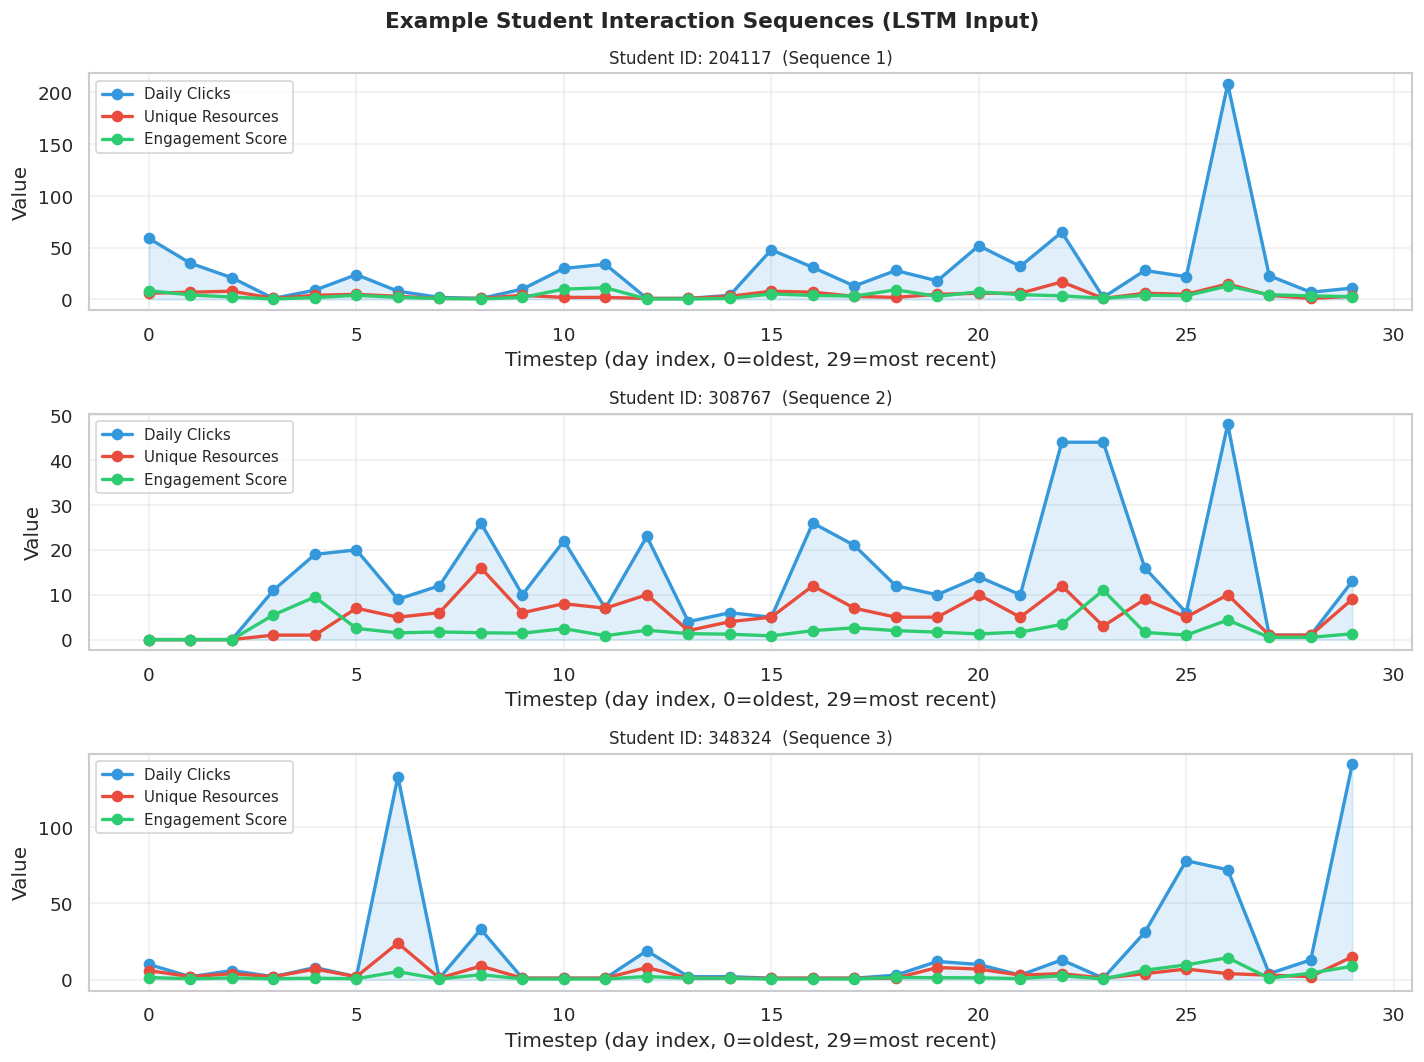

In [ ]:
# ── Visualise example sequences ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle(
    "Example Student Interaction Sequences (LSTM Input)", fontsize=13, fontweight="bold"
)

sample_indices = np.random.choice(len(X_sequences_all), 3, replace=False)
colors = ["#3498db", "#e74c3c", "#2ecc71"]
labels = ["Daily Clicks", "Unique Resources", "Engagement Score"]

for plot_i, sid_i in enumerate(sample_indices):
    ax = axes[plot_i]
    seq = X_sequences_all[sid_i]  # shape: (10, 3)
    x_ax = np.arange(N_STEPS)

    for feat_j, (color, label) in enumerate(zip(colors, labels)):
        ax.plot(x_ax, seq[:, feat_j], marker="o", color=color, label=label, linewidth=2)

    ax.fill_between(x_ax, seq[:, 0], alpha=0.15, color=colors[0])
    ax.set_title(
        f"Student ID: {student_ids_seq[sid_i]}  (Sequence {plot_i+1})", fontsize=10
    )
    ax.set_xlabel(f"Timestep (day index, 0=oldest, {N_STEPS -1 }=most recent)")
    ax.set_ylabel("Value")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Convert Spark → Pandas & Prepare for ML

At this point the distributed processing is complete. We convert the Spark DataFrame to Pandas for scikit-learn and TensorFlow compatibility.

In [ ]:
print("Converting Spark DataFrame to Pandas...")
t0 = time.time()

df = master.toPandas()

print(f"Conversion complete in {time.time() - t0:.1f}s")
print(f"Pandas DataFrame shape : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage           : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print(df.dtypes.to_string())


Converting Spark DataFrame to Pandas...
Conversion complete in 31.1s
Pandas DataFrame shape : 40,801 rows x 44 columns
Memory usage           : 27.75 MB

code_module                      object
code_presentation                object
id_student                        int32
gender                           object
region                           object
highest_education                object
imd_band                         object
age_band                         object
num_of_prev_attempts              int32
studied_credits                   int32
disability                       object
final_result                     object
total_clicks                      int64
avg_clicks_per_day              float64
max_clicks_single_day             int32
active_days                       int64
click_std                       float64
unique_resources_accessed         int64
avg_assessment_score            float64
max_assessment_score              int32
min_assessment_score              int32
score_

## 9. Transform Target Variable

The original `final_result` column has 4 values. We remap them to 3 classes:

| Original | New Class | Rationale |
|----------|-----------|-----------|
| `Pass` | `pass` | Successful completion |
| `Distinction` | `pass` | High achievement: grouped with pass |
| `Fail` | `fail` | Did not meet passing criteria |
| `Withdrawn` | `at_risk` | Withdrew before completion: strongest at-risk signal |

Target class distribution:
         count  percentage
target                    
pass     18306        44.9
at_risk  14017        34.4
fail      8478        20.8


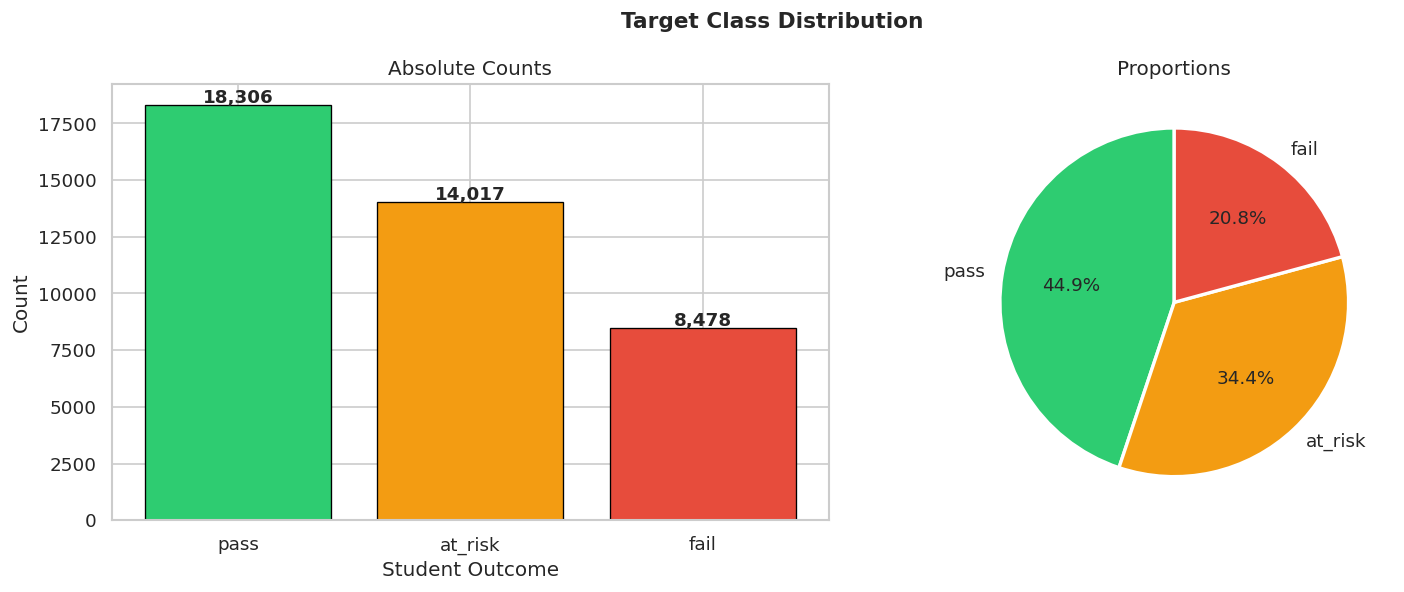


Imbalance ratios vs majority class:
  pass    : 1 : 1.0
  at_risk : 1 : 1.3
  fail    : 1 : 2.2


In [ ]:
# ── Map target classes ────────────────────────────────────────────────────────
CLASS_MAP = {
    "Pass": "pass",
    "Distinction": "pass",
    "Fail": "fail",
    "Withdrawn": "at_risk",
}

df["target"] = df["final_result"].map(CLASS_MAP)

print("Target class distribution:")
dist = df["target"].value_counts()
dist_pct = df["target"].value_counts(normalize=True).mul(100).round(1)
summary = pd.DataFrame({"count": dist, "percentage": dist_pct})
print(summary.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Target Class Distribution", fontsize=13, fontweight="bold")

colors = {"pass": "#2ecc71", "fail": "#e74c3c", "at_risk": "#f39c12"}
color_list = [colors[c] for c in dist.index]

# Bar chart
axes[0].bar(dist.index, dist.values, color=color_list, edgecolor="black", linewidth=0.8)
axes[0].set_title("Absolute Counts")
axes[0].set_xlabel("Student Outcome")
axes[0].set_ylabel("Count")
for i, (idx, val) in enumerate(dist.items()):
    axes[0].text(i, val + 100, f"{val:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    dist.values,
    labels=dist.index,
    colors=color_list,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Proportions")

plt.tight_layout()
plt.show()

# Imbalance ratio
majority = dist.max()
print("\nImbalance ratios vs majority class:")
for cls, cnt in dist.items():
    print(f"  {cls:8s}: 1 : {majority/cnt:.1f}")


## 10. Exploratory Data Analysis (EDA)

In-depth exploration across 5 dimensions:
1. Feature statistics by class
2. Correlation with target
3. Engagement comparison (pass vs fail vs at_risk)
4. At-risk student characteristics
5. Assessment performance distribution

In [ ]:
# ── 10.1 Summary statistics by class ─────────────────────────────────────────
key_numeric = [
    "total_clicks",
    "avg_clicks_per_day",
    "max_clicks_single_day",
    "active_days",
    "inactivity_days",
    "inactivity_rate",
    "avg_assessment_score",
    "total_assessments_submitted",
    "failed_assessments_count",
    "assessment_completion_rate",
    "composite_risk_score",
]

# Keep only those that exist in df
key_numeric = [c for c in key_numeric if c in df.columns]

print("Mean values by target class:")
print(df.groupby("target")[key_numeric].mean().round(2).T.to_string())


Mean values by target class:
target                       at_risk    fail     pass
total_clicks                  825.24  880.07  2494.35
avg_clicks_per_day              2.59    3.13     3.71
max_clicks_single_day          39.60   47.17    76.27
active_days                    37.68   42.21   104.00
inactivity_days               218.00  212.48   152.91
inactivity_rate                 0.85    0.83     0.59
avg_assessment_score           40.78   53.95    77.97
total_assessments_submitted     3.45    5.16    10.25
failed_assessments_count        0.36    0.67     0.28
assessment_completion_rate     36.27   53.45   110.17
composite_risk_score            1.62    1.13     0.08


In [ ]:
# ── 10.2 Point-biserial correlation with target ───────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["id_student", "target"]]

y_binary = (df["target"] == "pass").astype(int)

corr_records = []
for col_name in numeric_cols:
    valid = df[col_name].dropna()
    if len(valid) == 0 or valid.std() == 0:
        continue
    try:
        corr, pval = pointbiserialr(y_binary.loc[valid.index], valid)
        corr_records.append({"feature": col_name, "correlation": corr, "p_value": pval})
    except Exception:
        pass

corr_df = pd.DataFrame(corr_records).sort_values("correlation", ascending=False)

print("Top 10 positive correlations with 'pass' outcome:")
print(corr_df.head(10).to_string(index=False))
print("\nTop 10 negative correlations (associated with fail/at_risk):")
print(corr_df.tail(10).to_string(index=False))


Top 10 positive correlations with 'pass' outcome:
                    feature  correlation  p_value
 assessment_completion_rate     0.568453      0.0
total_assessments_submitted     0.560711      0.0
                  tma_count     0.528739      0.0
                active_days     0.528373      0.0
       max_assessment_score     0.527988      0.0
       avg_assessment_score     0.525891      0.0
    passing_assessment_rate     0.472473      0.0
  unique_resources_accessed     0.410070      0.0
       min_assessment_score     0.397208      0.0
               total_clicks     0.389867      0.0

Top 10 negative correlations (associated with fail/at_risk):
                feature  correlation       p_value
   num_of_prev_attempts    -0.119118 8.195182e-129
        studied_credits    -0.161318 6.088837e-236
    date_unregistration    -0.234491  0.000000e+00
    low_engagement_risk    -0.347881  0.000000e+00
         low_score_risk    -0.469905  0.000000e+00
        inactivity_days    -0.50

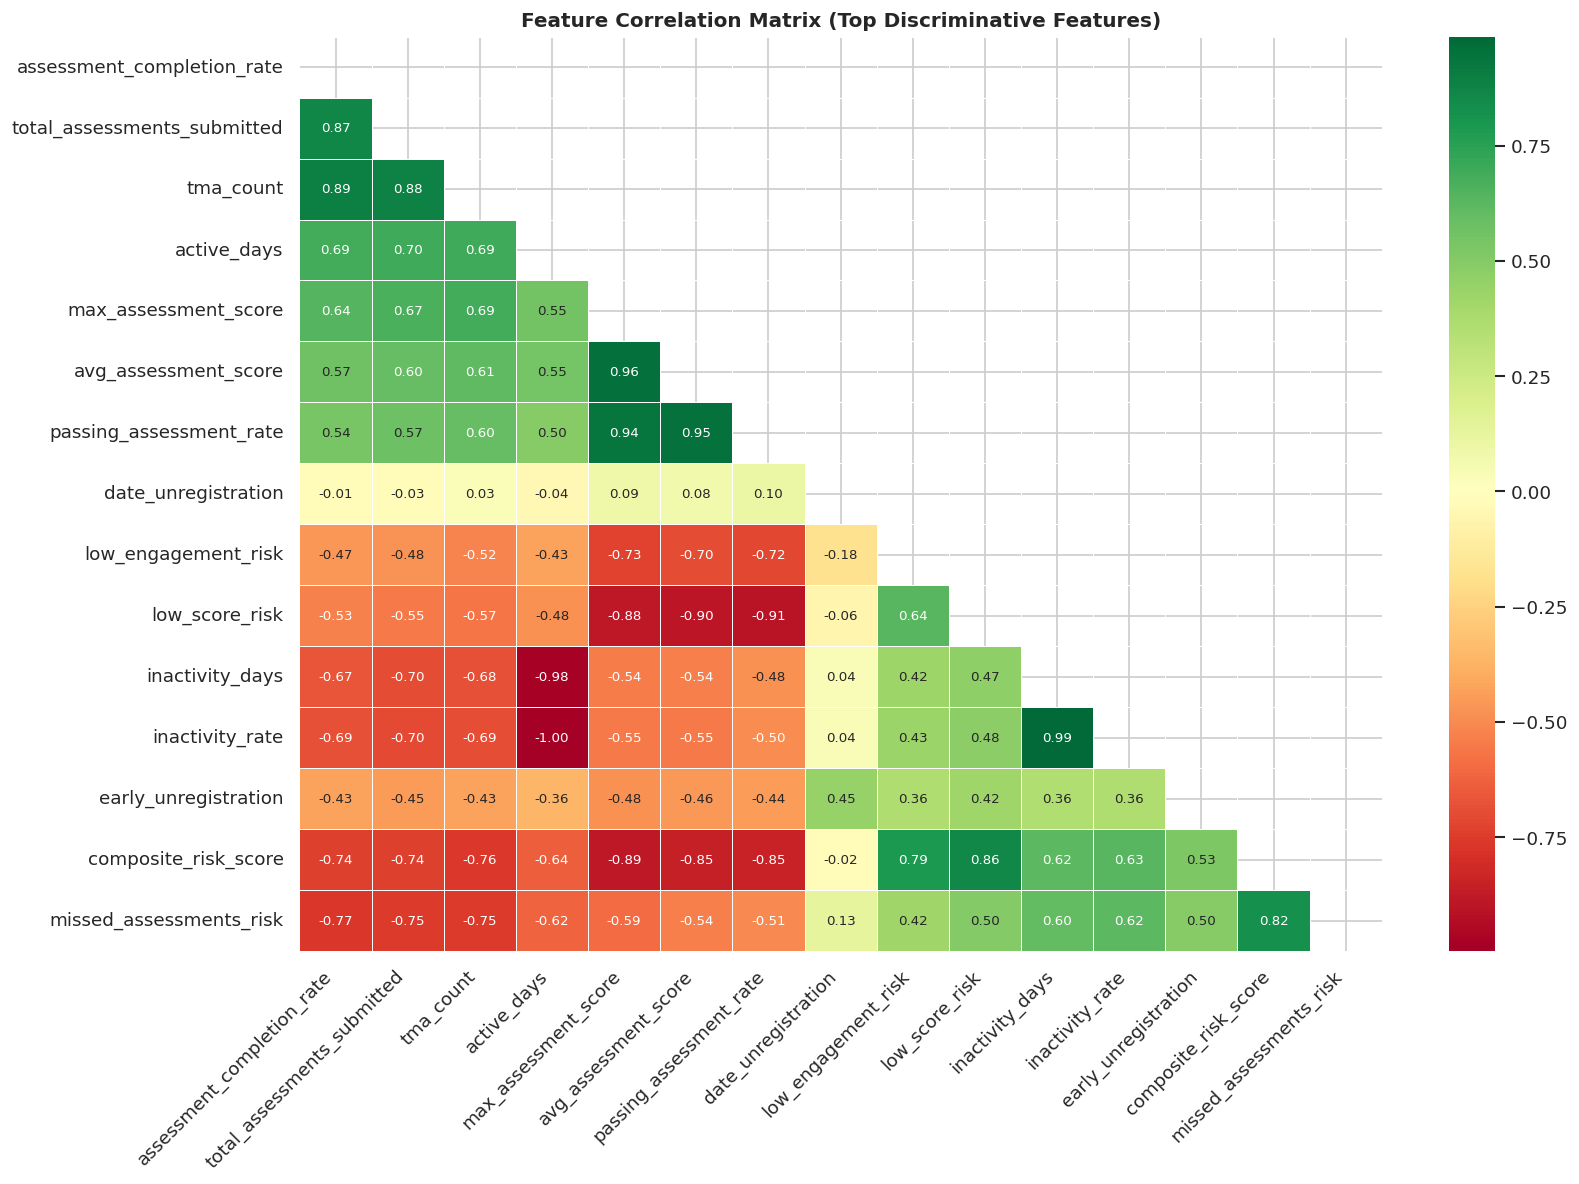

In [ ]:
# ── Correlation heatmap (top 15 features) ────────────────────────────────────
top_features = corr_df.head(7)["feature"].tolist() + corr_df.tail(8)["feature"].tolist()
top_features = list(dict.fromkeys(top_features))  # deduplicate

corr_matrix = df[top_features].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title(
    "Feature Correlation Matrix (Top Discriminative Features)",
    fontweight="bold",
    fontsize=12,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


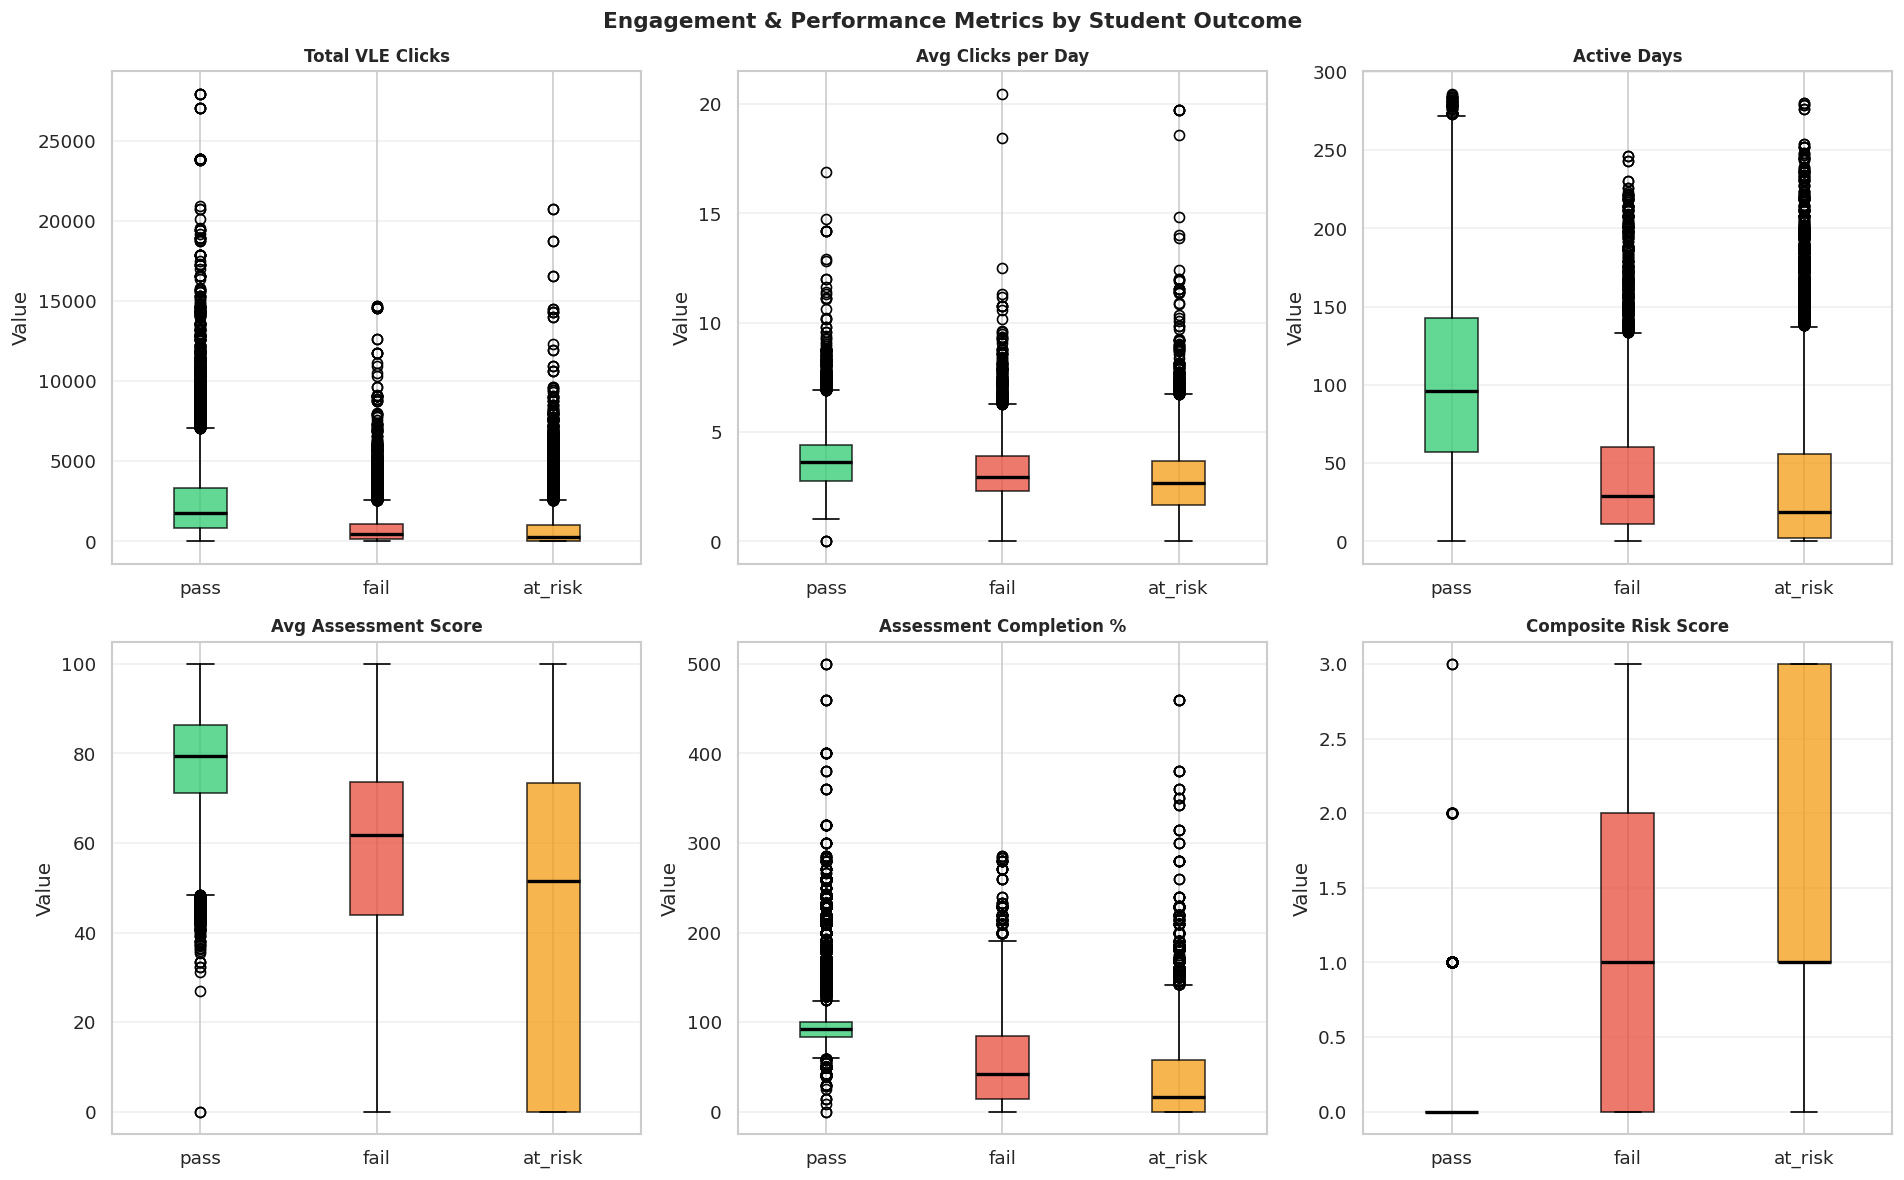

In [ ]:
# ── 10.3 Box plots: engagement by outcome ────────────────────────────────────
metrics_to_plot = [
    ("total_clicks", "Total VLE Clicks"),
    ("avg_clicks_per_day", "Avg Clicks per Day"),
    ("active_days", "Active Days"),
    ("avg_assessment_score", "Avg Assessment Score"),
    ("assessment_completion_rate", "Assessment Completion %"),
    ("composite_risk_score", "Composite Risk Score"),
]
metrics_to_plot = [(c, l) for c, l in metrics_to_plot if c in df.columns]

outcome_order = ["pass", "fail", "at_risk"]
palette = {"pass": "#2ecc71", "fail": "#e74c3c", "at_risk": "#f39c12"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Engagement & Performance Metrics by Student Outcome",
    fontsize=13,
    fontweight="bold",
)
axes = axes.flatten()

for idx, (metric, label) in enumerate(metrics_to_plot):
    ax = axes[idx]
    data_groups = [
        df[df["target"] == cls][metric].dropna().values for cls in outcome_order
    ]
    bp = ax.boxplot(
        data_groups,
        labels=outcome_order,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
    )
    for patch, cls in zip(bp["boxes"], outcome_order):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.75)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [ ]:
# ── 10.4 At-risk vs Successful student profile ────────────────────────────────
profile_features = [c for c in key_numeric if c in df.columns]

at_risk_df = df[df["target"] == "at_risk"]
successful_df = df[df["target"] == "pass"]

print("AT-RISK vs SUCCESSFUL STUDENT PROFILE")
print("=" * 70)
print(f"  {'Feature':<40} {'At-Risk':>12} {'Successful':>12} {'Ratio':>8}")
print("-" * 70)
for feat in profile_features:
    ar_val = at_risk_df[feat].mean()
    su_val = successful_df[feat].mean()
    ratio = ar_val / su_val if su_val != 0 else float("inf")
    print(f"  {feat:<40} {ar_val:>12.2f} {su_val:>12.2f} {ratio:>8.2f}x")


AT-RISK vs SUCCESSFUL STUDENT PROFILE
  Feature                                       At-Risk   Successful    Ratio
----------------------------------------------------------------------
  total_clicks                                   825.24      2494.35     0.33x
  avg_clicks_per_day                               2.59         3.71     0.70x
  max_clicks_single_day                           39.60        76.27     0.52x
  active_days                                     37.68       104.00     0.36x
  inactivity_days                                218.00       152.91     1.43x
  inactivity_rate                                  0.85         0.59     1.43x
  avg_assessment_score                            40.78        77.97     0.52x
  total_assessments_submitted                      3.45        10.25     0.34x
  failed_assessments_count                         0.36         0.28     1.29x
  assessment_completion_rate                      36.27       110.17     0.33x
  composite_risk_score 

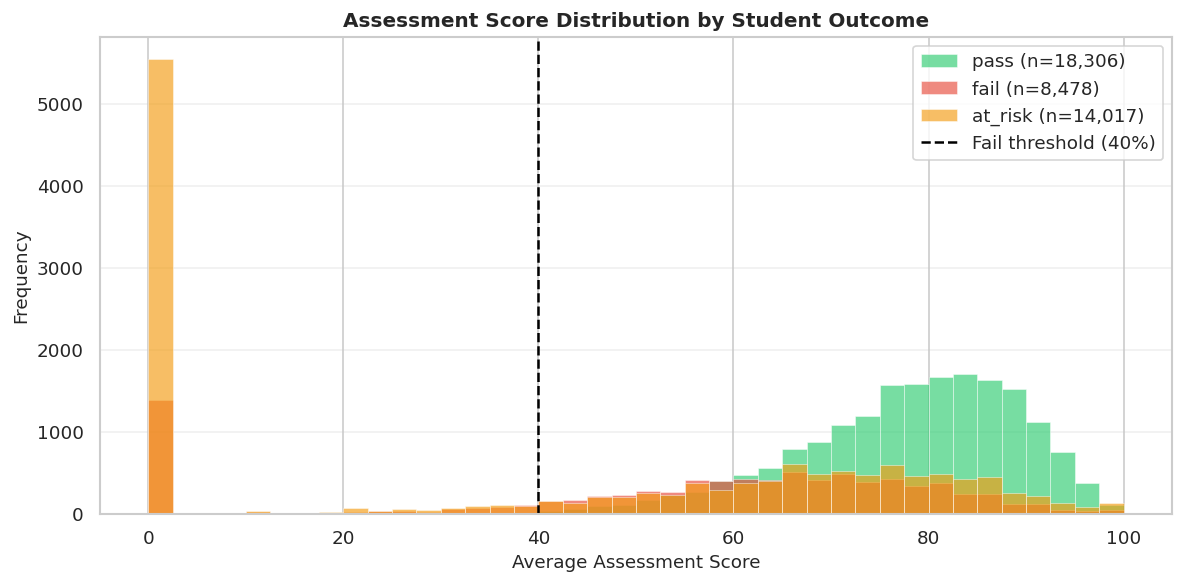

In [ ]:
# ── 10.5 Assessment score distribution ───────────────────────────────────────
if "avg_assessment_score" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))

    for outcome in outcome_order:
        data = df[df["target"] == outcome]["avg_assessment_score"].dropna()
        ax.hist(
            data,
            bins=40,
            alpha=0.65,
            color=palette[outcome],
            label=f"{outcome} (n={len(data):,})",
            edgecolor="white",
            linewidth=0.4,
        )

    ax.axvline(
        40, color="black", linestyle="--", linewidth=1.5, label="Fail threshold (40%)"
    )
    ax.set_xlabel("Average Assessment Score", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.set_title(
        "Assessment Score Distribution by Student Outcome",
        fontweight="bold",
        fontsize=12,
    )
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


## 11. Data Encoding

**Categorical features** (gender, region, highest_education, imd_band, age_band, code_module) are one-hot encoded using `pd.get_dummies()`. The **target variable** is label-encoded:

- `at_risk` → 0
- `fail`    → 1
- `pass`    → 2

In [ ]:
# ── Columns to drop before encoding ──────────────────────────────────────────
DROP_COLS = [
    "id_student",
    "code_presentation",
    "final_result",
    "date_registration",
    "date_unregistration",
    "date_submitted",  # if present
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# ── Categorical columns to one-hot encode ─────────────────────────────────────
CAT_COLS = [
    "disability",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "code_module",
]
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

print("Categorical columns to encode:", CAT_COLS)

# Store target before encoding
y_raw = df["target"].copy()

# Drop irrelevant columns
df_ml = df.drop(columns=DROP_COLS + ["target"], errors="ignore")

# One-hot encode categoricals
df_ml = pd.get_dummies(df_ml, columns=CAT_COLS, drop_first=False)

print(f"\nShape after one-hot encoding: {df_ml.shape}")
print(f"  Original columns    : {df.shape[1]}")
print(f"  After encoding      : {df_ml.shape[1]}")

# ── Label-encode target ───────────────────────────────────────────────────────
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

print(f"\nTarget classes (encoded order): {list(label_encoder.classes_)}")
print(f"  0 = {label_encoder.classes_[0]}")
print(f"  1 = {label_encoder.classes_[1]}")
print(f"  2 = {label_encoder.classes_[2]}")


Categorical columns to encode: ['disability', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'code_module']

Shape after one-hot encoding: (40801, 75)
  Original columns    : 45
  After encoding      : 75

Target classes (encoded order): ['at_risk', 'fail', 'pass']
  0 = at_risk
  1 = fail
  2 = pass


In [ ]:
# REMOVE
# List non-numeric columns (for debugging)
non_numeric_cols = df_ml.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns in df_ml:", non_numeric_cols)


Non-numeric columns in df_ml: ['disability_N', 'disability_Y', 'gender_F', 'gender_M', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_0-10%', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'imd_band_Unknown', 'age_band_0-35', 'age_band_35-55', 'age_band_55<=', 'code_module_AAA', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'c

In [ ]:
# Replace any remaining infinities or NaNs with 0
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ml.fillna(0, inplace=True)

X = df_ml.values.astype(np.float32)
y = y_encoded

print(f"Feature matrix X : {X.shape}")
print(f"Target vector y  : {y.shape}")
print(f"Classes          : {label_encoder.classes_}")


Feature matrix X : (40801, 75)
Target vector y  : (40801,)
Classes          : ['at_risk' 'fail' 'pass']


## 12. Train / Validation / Test Split (70 / 15 / 15)

We use **stratified splitting** to preserve class proportions across all three splits, essential for imbalanced datasets.


In [ ]:
# ── Step 1: 70% train, 30% temp ───────────────────────────────────────────────
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, np.arange(len(X)), test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

# ── Step 2: 50% of temp → val, 50% → test (= 15% each of total) ───────────────
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)


## 13. Feature Scaling

kNN is highly sensitive to feature scales (Euclidean distance), and neural networks converge faster on standardised input. We apply **StandardScaler** (`mean=0, std=1`) fitted on the training split only to avoid data leakage.

In [ ]:
# ── Scale AFTER splitting ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit only on train
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

total = len(X)
print(f"Train      : {len(X_train):>6,} samples ({len(X_train)/total*100:.1f}%)")
print(f"Validation : {len(X_val):>6,} samples ({len(X_val)/total*100:.1f}%)")
print(f"Test       : {len(X_test):>6,} samples ({len(X_test)/total*100:.1f}%)")

print("\nClass distribution of Train:")
for i, cls in enumerate(label_encoder.classes_):
    n = (y_train == i).sum()
    print(f"  {cls:8s}: {n:,} ({n/len(y_train)*100:.1f}%)")

print("\nClass distribution of Test:")
for i, cls in enumerate(label_encoder.classes_):
    n = (y_test == i).sum()
    print(f"  {cls:8s}: {n:,} ({n/len(y_test)*100:.1f}%)")


Train      : 28,560 samples (70.0%)
Validation :  6,120 samples (15.0%)
Test       :  6,121 samples (15.0%)

Class distribution of Train:
  at_risk : 9,812 (34.4%)
  fail    : 5,934 (20.8%)
  pass    : 12,814 (44.9%)

Class distribution of Test:
  at_risk : 2,103 (34.4%)
  fail    : 1,272 (20.8%)
  pass    : 2,746 (44.9%)


## 14. Handle Class Imbalance

The dataset is imbalanced as more students pass than fail or withdraw. We address this with **class weights**: minority classes receive higher penalties during training, forcing models to take them seriously. This is preferable to oversampling for interpretability.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)

class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}

print("Computed class weights (balanced):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls:8s} (label {i}): weight = {class_weights_dict[i]:.4f}")

print("""
INTERPRETATION:
  Weight > 1: model penalises misclassification of this class MORE
  Weight < 1: model has lower penalty for misclassifying this class
  Balanced : weights inversely proportional to class frequencies
""")


Computed class weights (balanced):
  at_risk  (label 0): weight = 0.9702
  fail     (label 1): weight = 1.6043
  pass     (label 2): weight = 0.7429

INTERPRETATION:
  Weight > 1: model penalises misclassification of this class MORE
  Weight < 1: model has lower penalty for misclassifying this class
  Balanced : weights inversely proportional to class frequencies



In [ ]:
# ── Shared evaluation helper ──────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, model_name, set_name):
    """
    Compute and display comprehensive classification metrics.

    Parameters
    ----------
    y_true      : array-like — ground truth labels
    y_pred      : array-like — predicted labels
    model_name  : str — display name of the model
    set_name    : str — 'Train', 'Validation', or 'Test'

    Returns
    -------
    dict of scalar metrics
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n  [{model_name}] — {set_name}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Precision : {prec:.4f}  (macro)")
    print(f"    Recall    : {rec:.4f}  (macro)")
    print(f"    F1-Score  : {f1:.4f}  (macro)")
    print(f"    F1-Score  : {f1_w:.4f}  (weighted)")

    return {
        "model": model_name,
        "set": set_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_macro": f1,
        "F1_weighted": f1_w,
    }


## 15. Model 1 — k-Nearest Neighbours (kNN)

**Why kNN?**
kNN is a non-parametric, instance-based classifier. It makes no assumptions about the data distribution and serves as a transparent baseline. It is highly sensitive to feature scaling (already applied) and can suffer from the *curse of dimensionality*.

**Configuration:**
- `n_neighbors = 7` (odd to break ties)
- `metric = 'euclidean'`
- `weights = 'uniform'`

  MODEL 1: k-Nearest Neighbours (kNN)

Training time: 0.003s

  [kNN] — Train
    Accuracy  : 0.8239
    Precision : 0.8157  (macro)
    Recall    : 0.7695  (macro)
    F1-Score  : 0.7815  (macro)
    F1-Score  : 0.8143  (weighted)

  [kNN] — Validation
    Accuracy  : 0.7680
    Precision : 0.7392  (macro)
    Recall    : 0.7041  (macro)
    F1-Score  : 0.7108  (macro)
    F1-Score  : 0.7544  (weighted)

  [kNN] — Test
    Accuracy  : 0.7634
    Precision : 0.7341  (macro)
    Recall    : 0.6982  (macro)
    F1-Score  : 0.7045  (macro)
    F1-Score  : 0.7490  (weighted)


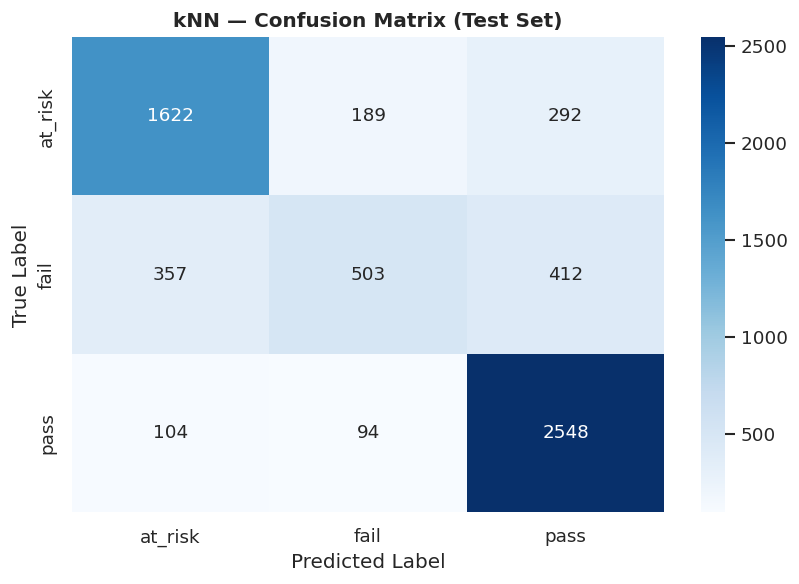


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

     at_risk       0.78      0.77      0.77      2103
        fail       0.64      0.40      0.49      1272
        pass       0.78      0.93      0.85      2746

    accuracy                           0.76      6121
   macro avg       0.73      0.70      0.70      6121
weighted avg       0.75      0.76      0.75      6121



In [ ]:
print("=" * 60)
print("  MODEL 1: k-Nearest Neighbours (kNN)")
print("=" * 60)

knn = KNeighborsClassifier(
    n_neighbors=7, metric="euclidean", weights="uniform", n_jobs=-1
)

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
knn.fit(X_train, y_train)
knn_train_time = time.time() - t0
print(f"\nTraining time: {knn_train_time:.3f}s")

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_knn_train = knn.predict(X_train)
y_pred_knn_val = knn.predict(X_val)
y_pred_knn_test = knn.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
knn_train_metrics = evaluate_model(y_train, y_pred_knn_train, "kNN", "Train")
knn_val_metrics = evaluate_model(y_val, y_pred_knn_val, "kNN", "Validation")
knn_test_metrics = evaluate_model(y_test, y_pred_knn_test, "kNN", "Test")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_knn = confusion_matrix(y_test, y_pred_knn_test)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("kNN — Confusion Matrix (Test Set)", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report (Test Set):")
print(
    classification_report(
        y_test, y_pred_knn_test, target_names=label_encoder.classes_, zero_division=0
    )
)


## 16. Model 2 — Random Forest

**Why Random Forest?**
An ensemble of decision trees, each trained on a random bootstrap sample with a random feature subset. Key advantages:

- Handles non-linear relationships naturally
- Built-in feature importance ranking (Gini impurity based)
- `class_weight='balanced'` natively handles imbalance
- Less prone to overfitting than a single deep tree

**Configuration:** `n_estimators=100`, `class_weight='balanced'`, `random_state=42`


In [ ]:
print("=" * 60)
print("  MODEL 2: Random Forest Classifier")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",  # sqrt(n_features) features per split
    bootstrap=True,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

t0 = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - t0
print(f"\nTraining time: {rf_train_time:.3f}s")

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_val = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
rf_train_metrics = evaluate_model(y_train, y_pred_rf_train, "Random Forest", "Train")
rf_val_metrics = evaluate_model(y_val, y_pred_rf_val, "Random Forest", "Validation")
rf_test_metrics = evaluate_model(y_test, y_pred_rf_test, "Random Forest", "Test")

# ── Feature importance ────────────────────────────────────────────────────────
feat_names = df_ml.columns.tolist()
importances = rf.feature_importances_

importance_df = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))


  MODEL 2: Random Forest Classifier

Training time: 3.005s

  [Random Forest] — Train
    Accuracy  : 1.0000
    Precision : 1.0000  (macro)
    Recall    : 1.0000  (macro)
    F1-Score  : 1.0000  (macro)
    F1-Score  : 1.0000  (weighted)

  [Random Forest] — Validation
    Accuracy  : 0.8954
    Precision : 0.8892  (macro)
    Recall    : 0.8684  (macro)
    F1-Score  : 0.8771  (macro)
    F1-Score  : 0.8937  (weighted)

  [Random Forest] — Test
    Accuracy  : 0.8989
    Precision : 0.8930  (macro)
    Recall    : 0.8733  (macro)
    F1-Score  : 0.8816  (macro)
    F1-Score  : 0.8973  (weighted)

Top 20 Most Important Features:
                     feature  importance
        early_unregistration    0.225488
  assessment_completion_rate    0.066251
        composite_risk_score    0.055550
     missed_assessments_risk    0.037765
        avg_assessment_score    0.037294
                   tma_count    0.034192
                 active_days    0.033160
             inactivity_rate    0

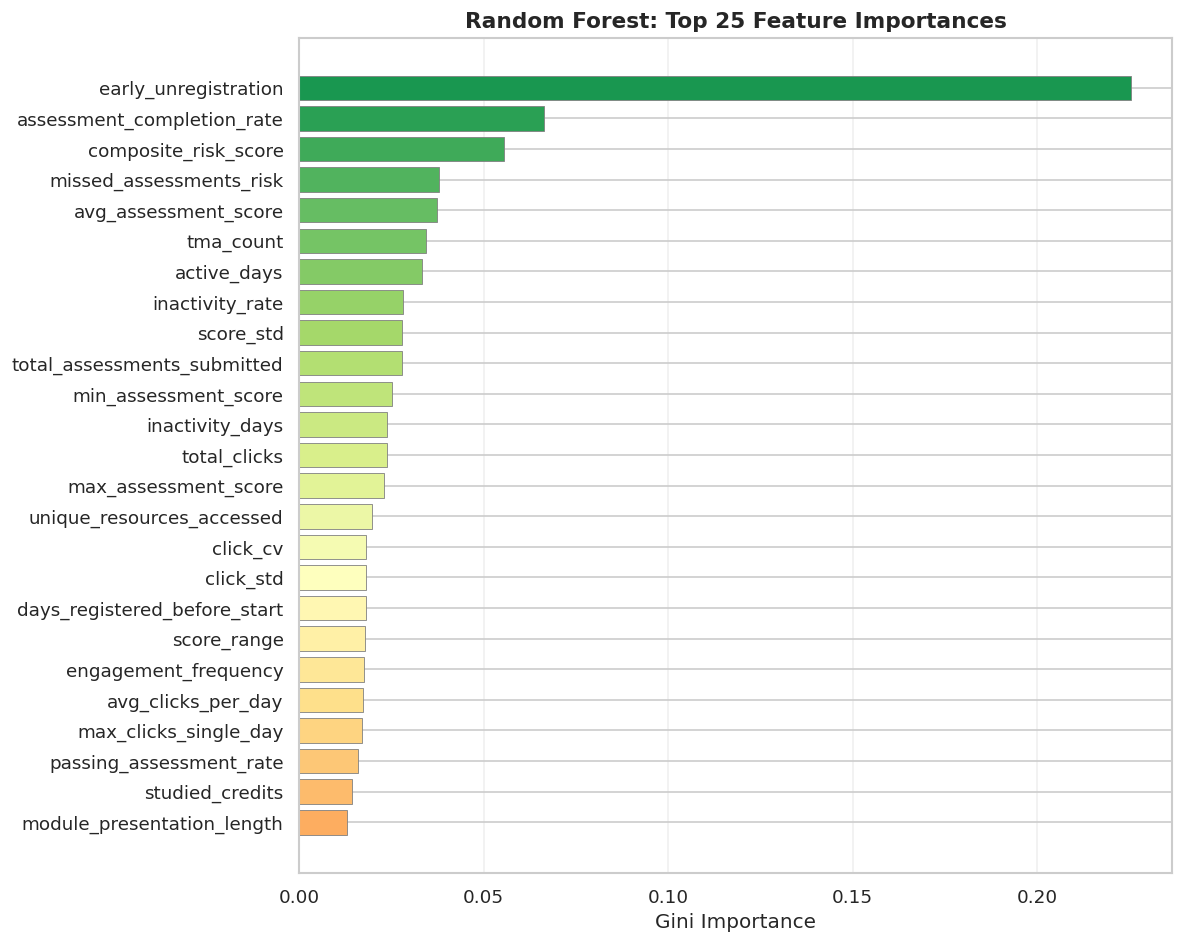

In [ ]:
# ── 1. Feature Importance Bar Chart ──────────────────────────────────────────
top_n = 25
top_imp = importance_df.head(top_n)

# Create a figure specifically for feature importance
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_imp["feature"][::-1],
    top_imp["importance"][::-1],
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n)),
    edgecolor="grey",
    linewidth=0.5,
)
ax.set_title(
    f"Random Forest: Top {top_n} Feature Importances", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Gini Importance")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


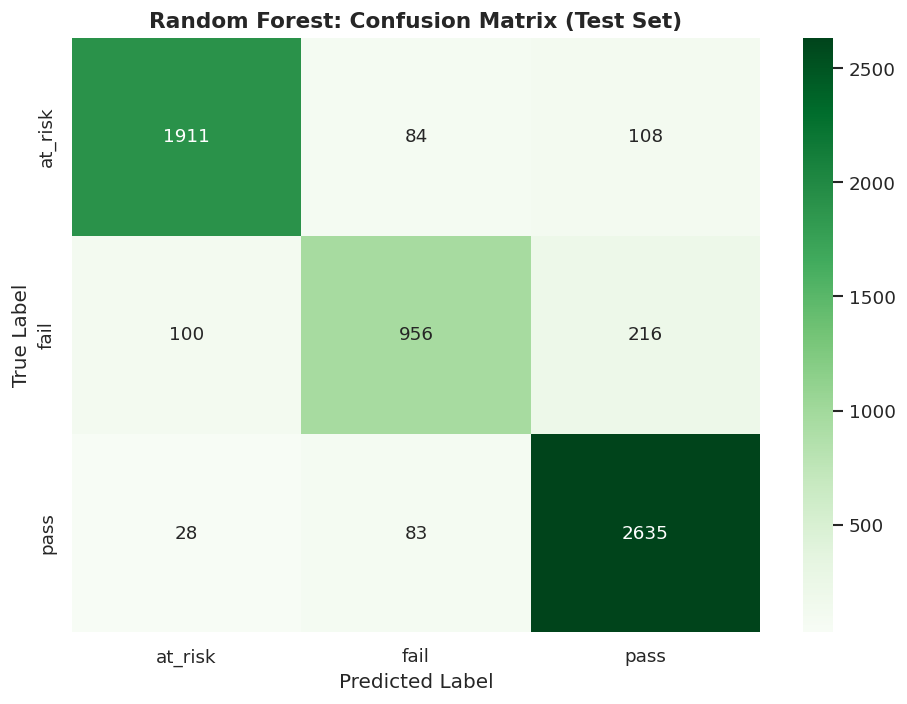


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

     at_risk       0.94      0.91      0.92      2103
        fail       0.85      0.75      0.80      1272
        pass       0.89      0.96      0.92      2746

    accuracy                           0.90      6121
   macro avg       0.89      0.87      0.88      6121
weighted avg       0.90      0.90      0.90      6121



In [ ]:
# ── 2. Confusion Matrix ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf_test)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    ax=ax,
)
ax.set_title(
    "Random Forest: Confusion Matrix (Test Set)", fontsize=13, fontweight="bold"
)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# ── 3. Classification Report ─────────────────────────────────────────────────
print("\nDetailed Classification Report (Test Set):")
print(
    classification_report(
        y_test, y_pred_rf_test, target_names=label_encoder.classes_, zero_division=0
    )
)


## 17. Model 3: LSTM Neural Network

**Why LSTM?**
Standard ML models treat each student as a static feature vector. LSTM (**Long Short-Term Memory**) networks learn from *temporal sequences*, capturing the order and dynamics of student engagement over time and has a clear advantage for behavioural data.

**Architecture:**
```
Input (10 timesteps × 3 features)
  → Masking (ignore zero-padded timesteps)
  → LSTM (300 units, return_sequences=True)
  → Dropout (0.1)
  → LSTM (300 units, return_sequences=False)
  → Dropout (0.1)
  → Dense (128, ReLU)
  → Dropout (0.2)
  → Dense (3, Softmax)   ← output probability over 3 classes
```

In [ ]:
# ── Align sequence tensor with tabular split indices ──────────────────────────
print("Preparing LSTM sequential inputs...")

# Build a mapping: student_id → row index in X_sequences_all
sid_to_seq_idx = {sid: i for i, sid in enumerate(student_ids_seq)}

# Get student ids in the same order as df_ml
df_student_ids = df["id_student"].values


def get_seq_indices(split_row_indices, df_sids, sid_to_idx):
    """Return sequence indices for a given split."""
    seq_idx = []
    for ri in split_row_indices:
        sid = df_sids[ri]
        if sid in sid_to_idx:
            seq_idx.append(sid_to_idx[sid])
        else:
            seq_idx.append(None)
    return seq_idx


# Build per-split sequence arrays
def build_seq_split(split_row_indices, df_sids, sid_to_idx, X_seq_all):
    """
    Build (n, n_steps, n_features) arrays for a given data split.
    Students without sequence data get a zero-padded sequence.
    """
    zero_seq = np.zeros((N_STEPS, N_FEATURES), dtype=np.float32)
    seqs = []
    for ri in split_row_indices:
        sid = df_sids[ri]
        idx = sid_to_idx.get(sid)
        seqs.append(X_seq_all[idx] if idx is not None else zero_seq)
    return np.array(seqs, dtype=np.float32)


X_lstm_train = build_seq_split(
    idx_train, df_student_ids, sid_to_seq_idx, X_sequences_all
)
X_lstm_val = build_seq_split(idx_val, df_student_ids, sid_to_seq_idx, X_sequences_all)
X_lstm_test = build_seq_split(idx_test, df_student_ids, sid_to_seq_idx, X_sequences_all)

print(f"LSTM Train shape : {X_lstm_train.shape}")
print(f"LSTM Val shape   : {X_lstm_val.shape}")
print(f"LSTM Test shape  : {X_lstm_test.shape}")


Preparing LSTM sequential inputs...
LSTM Train shape : (28560, 30, 3)
LSTM Val shape   : (6120, 30, 3)
LSTM Test shape  : (6121, 30, 3)


In [ ]:
# ── Build LSTM model ──────────────────────────────────────────────────────────
n_classes = len(label_encoder.classes_)

lstm_model = Sequential(
    [
        # Masking Layer: tells LSTM to ignore timesteps that are all zeros (padding)
        Masking(mask_value=0.0, input_shape=(N_STEPS, N_FEATURES)),
        # First LSTM layer — returns a sequence for the second LSTM layer
        LSTM(units=300, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        # Second LSTM layer — returns only the final hidden state to Dense layer
        LSTM(units=300, return_sequences=False, dropout=0.1, recurrent_dropout=0.1),
        # Dense hidden layer for non-linear feature combination
        Dense(128, activation="relu"),
        Dropout(0.2),
        # Output layer: softmax → probability distribution over 3 classes
        Dense(n_classes, activation="softmax"),
    ],
    name="OULAD_LSTM",
)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_model.summary()


I0000 00:00:1778759008.001525      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778759008.007667      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "OULAD_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 300)        │       364,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 300)            │       721,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,124,915 (4.29 MB)

 Trainable params: 1,124,915 (4.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
callbacks_list = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

t0 = time.time()

history = lstm_model.fit(
    X_lstm_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_lstm_val, y_val),
    class_weight=class_weights_dict,
    callbacks=callbacks_list,
    verbose=1,
)

lstm_train_time = time.time() - t0
print(f"\nLSTM training completed in {lstm_train_time:.1f}s")
print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")


Epoch 1/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 175s 186ms/step - accuracy: 0.5278 - loss: 1.0207 - val_accuracy: 0.5696 - val_loss: 0.9145 - learning_rate: 0.0010
Epoch 2/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 162s 182ms/step - accuracy: 0.5777 - loss: 0.9399 - val_accuracy: 0.5889 - val_loss: 0.9010 - learning_rate: 0.0010
Epoch 3/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 162s 182ms/step - accuracy: 0.5872 - loss: 0.9275 - val_accuracy: 0.5830 - val_loss: 0.8875 - learning_rate: 0.0010
Epoch 4/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 157s 175ms/step - accuracy: 0.5894 - loss: 0.9186 - val_accuracy: 0.5768 - val_loss: 0.8953 - learning_rate: 0.0010
Epoch 5/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 162s 182ms/step - accuracy: 0.5879 - loss: 0.9161 - val_accuracy: 0.5781 - val_loss: 0.8897 - learning_rate: 0.0010
Epoch 6/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 162s 182ms/step - accuracy: 0.5948 - loss: 0.9093 - val_accuracy: 0.5954 - val_loss: 0.8708 - learning_rate: 0.0010
Epoch 7/50
893/893 ━━━━━━━━━━━━━━━━━━━━ 163s 182ms/step - accura

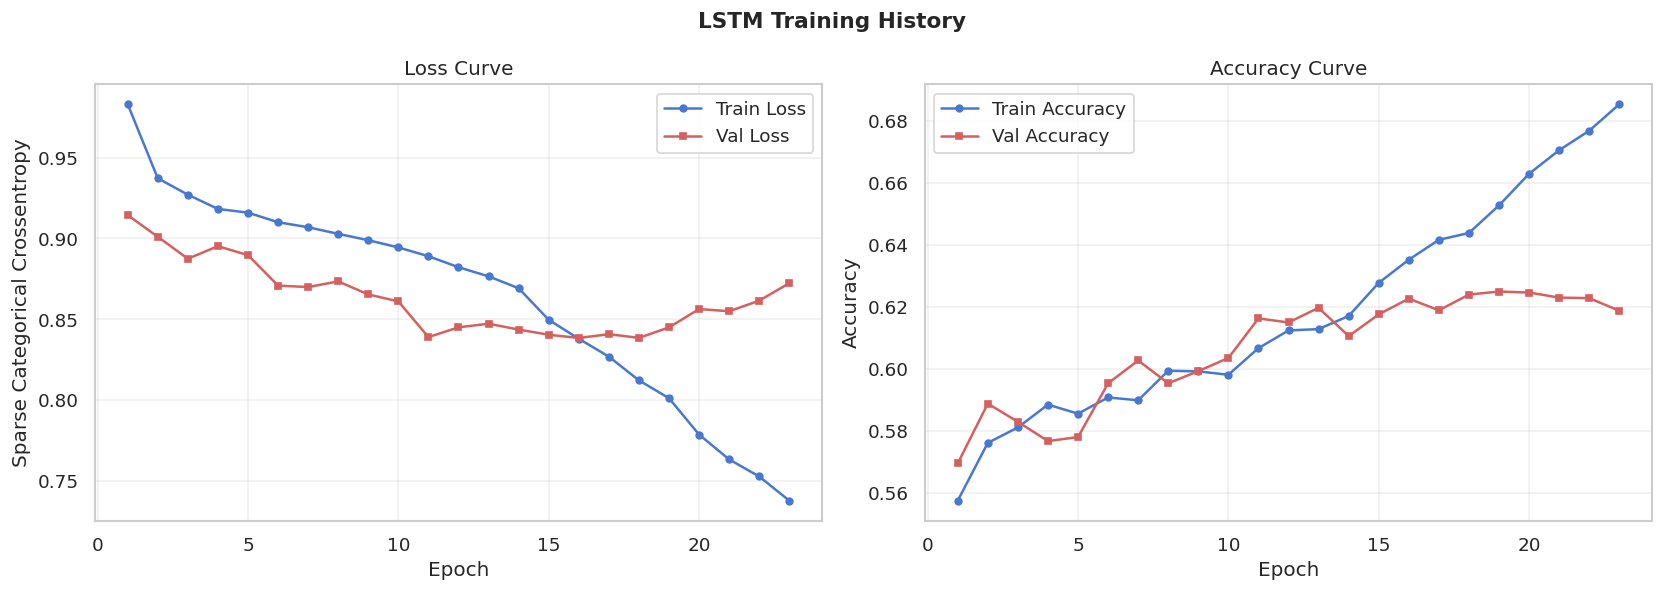

In [ ]:
# ── Training history plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Training History", fontsize=13, fontweight="bold")

epochs_ran = range(1, len(history.history["loss"]) + 1)

# Loss
axes[0].plot(
    epochs_ran, history.history["loss"], "b-o", markersize=4, label="Train Loss"
)
axes[0].plot(
    epochs_ran, history.history["val_loss"], "r-s", markersize=4, label="Val Loss"
)
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse Categorical Crossentropy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(
    epochs_ran, history.history["accuracy"], "b-o", markersize=4, label="Train Accuracy"
)
axes[1].plot(
    epochs_ran,
    history.history["val_accuracy"],
    "r-s",
    markersize=4,
    label="Val Accuracy",
)
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step

  [LSTM] — Test
    Accuracy  : 0.6200
    Precision : 0.5997  (macro)
    Recall    : 0.5715  (macro)
    F1-Score  : 0.5675  (macro)
    F1-Score  : 0.6109  (weighted)


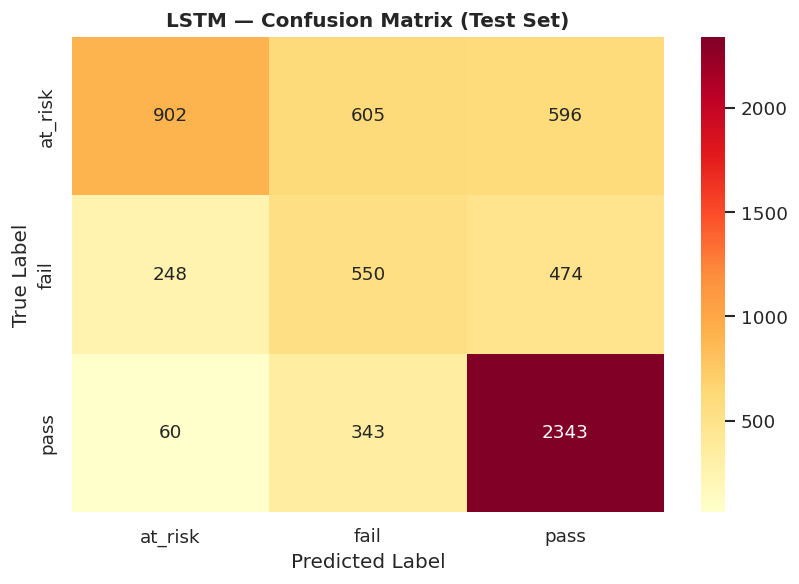


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

     at_risk       0.75      0.43      0.54      2103
        fail       0.37      0.43      0.40      1272
        pass       0.69      0.85      0.76      2746

    accuracy                           0.62      6121
   macro avg       0.60      0.57      0.57      6121
weighted avg       0.64      0.62      0.61      6121



In [ ]:
# ── Predict & evaluate ────────────────────────────────────────────────────────
y_pred_lstm_probs = lstm_model.predict(X_lstm_test)
y_pred_lstm_test = np.argmax(y_pred_lstm_probs, axis=1)

lstm_test_metrics = evaluate_model(y_test, y_pred_lstm_test, "LSTM", "Test")

# Confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm_test)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("LSTM — Confusion Matrix (Test Set)", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report (Test Set):")
print(
    classification_report(
        y_test, y_pred_lstm_test, target_names=label_encoder.classes_, zero_division=0
    )
)


## 18. Model Comparison

We aggregate all test-set metrics into a single comparison table and visualise the results. This enables a principled choice of the best model for deployment.

In [ ]:
# ── Build comparison table ────────────────────────────────────────────────────
comparison_data = {
    "Model": ["kNN", "Random Forest", "LSTM"],
    "Accuracy": [
        knn_test_metrics["Accuracy"],
        rf_test_metrics["Accuracy"],
        lstm_test_metrics["Accuracy"],
    ],
    "Precision (macro)": [
        knn_test_metrics["Precision"],
        rf_test_metrics["Precision"],
        lstm_test_metrics["Precision"],
    ],
    "Recall (macro)": [
        knn_test_metrics["Recall"],
        rf_test_metrics["Recall"],
        lstm_test_metrics["Recall"],
    ],
    "F1-Score (macro)": [
        knn_test_metrics["F1_macro"],
        rf_test_metrics["F1_macro"],
        lstm_test_metrics["F1_macro"],
    ],
    "F1-Score (weighted)": [
        knn_test_metrics["F1_weighted"],
        rf_test_metrics["F1_weighted"],
        lstm_test_metrics["F1_weighted"],
    ],
    "Training Time (s)": [
        round(knn_train_time, 2),
        round(rf_train_time, 2),
        round(lstm_train_time, 2),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index("Model")

print("MODEL COMPARISON — Test Set")
print("=" * 75)
print(comparison_df.round(4).to_string())
print("=" * 75)

best_model = comparison_df["Accuracy"].idxmax()
print(
    f"\n→ Best model by accuracy: {best_model} ({comparison_df.loc[best_model,'Accuracy']:.4f})"
)


MODEL COMPARISON — Test Set
               Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  F1-Score (weighted)  Training Time (s)
Model                                                                                                               
kNN              0.7634             0.7341          0.6982            0.7045               0.7490               0.00
Random Forest    0.8989             0.8930          0.8733            0.8816               0.8973               3.01
LSTM             0.6200             0.5997          0.5715            0.5675               0.6109            3757.14

→ Best model by accuracy: Random Forest (0.8989)


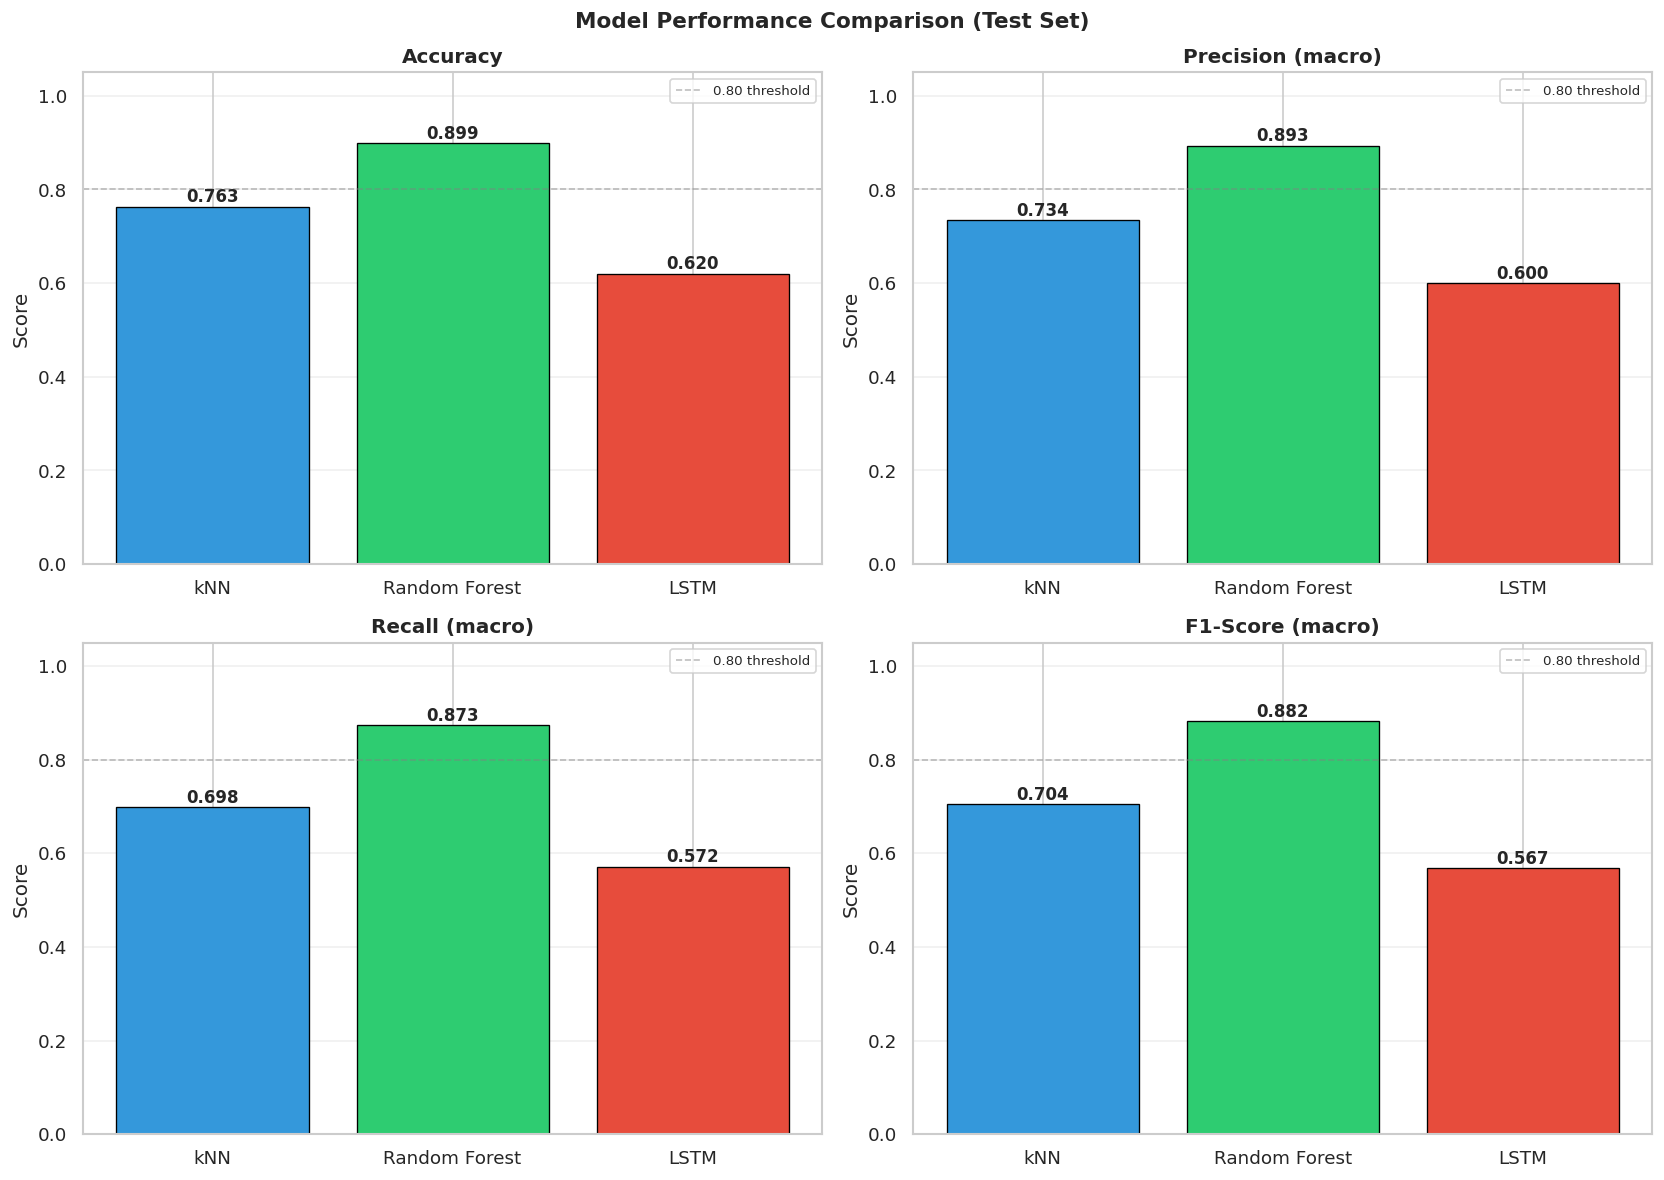

In [ ]:
# ── Comparison bar charts ─────────────────────────────────────────────────────
metrics_to_compare = [
    "Accuracy",
    "Precision (macro)",
    "Recall (macro)",
    "F1-Score (macro)",
]
model_colors = {"kNN": "#3498db", "Random Forest": "#2ecc71", "LSTM": "#e74c3c"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Performance Comparison (Test Set)", fontsize=13, fontweight="bold")
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_compare):
    ax = axes[idx]
    models = comparison_df.index.tolist()
    values = comparison_df[metric].tolist()
    colors = [model_colors[m] for m in models]

    bars = ax.bar(models, values, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.axhline(
        0.8,
        linestyle="--",
        color="grey",
        linewidth=1,
        alpha=0.5,
        label="0.80 threshold",
    )

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center",
            fontsize=10,
            fontweight="bold",
        )

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


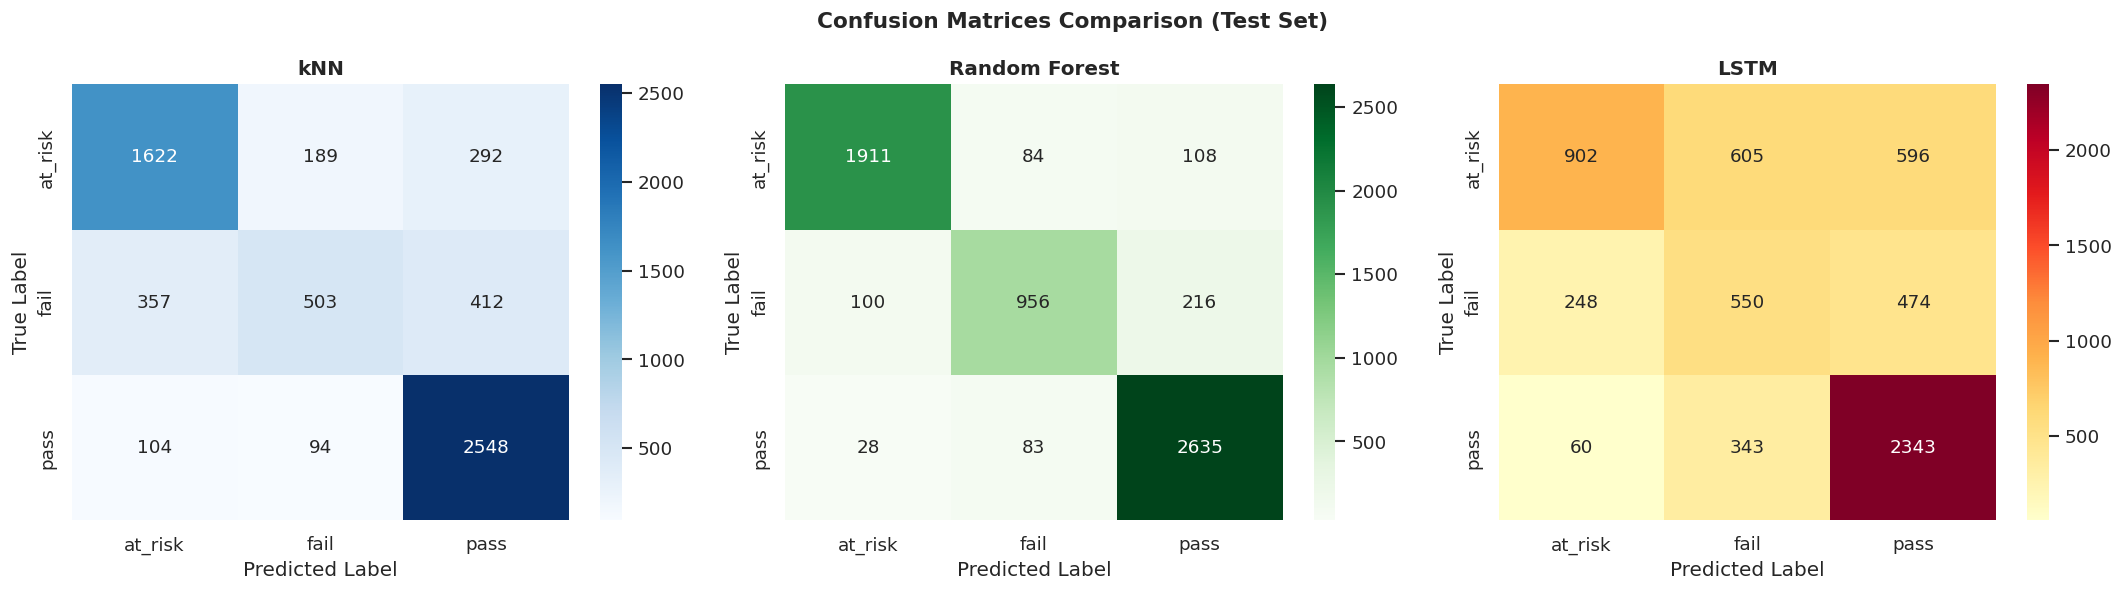


Model Trade-Off Summary:
Model              Interpretability   Speed              Key Strength
----------------------------------------------------------------------
kNN                High               Slow (large N)     Simple baseline
Random Forest      Medium             Fast               Feature importance
LSTM               Low                Medium             Temporal patterns


In [ ]:
# ── Side-by-side confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices Comparison (Test Set)", fontsize=13, fontweight="bold")

models_cms = [
    ("kNN", cm_knn, "Blues"),
    ("Random Forest", cm_rf, "Greens"),
    ("LSTM", cm_lstm, "YlOrRd"),
]

for ax, (name, cm, cmap) in zip(axes, models_cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax,
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# ── Model trade-off summary ────────────────────────────────────────────────────
tradeoffs = {
    "kNN": {
        "Interpretability": "High",
        "Speed": "Slow (large N)",
        "Strength": "Simple baseline",
    },
    "Random Forest": {
        "Interpretability": "Medium",
        "Speed": "Fast",
        "Strength": "Feature importance",
    },
    "LSTM": {
        "Interpretability": "Low",
        "Speed": "Medium",
        "Strength": "Temporal patterns",
    },
}

print("\nModel Trade-Off Summary:")
print(f"{'Model':<18} {'Interpretability':<18} {'Speed':<18} {'Key Strength'}")
print("-" * 70)
for model, details in tradeoffs.items():
    print(
        f"{model:<18} {details['Interpretability']:<18} {details['Speed']:<18} {details['Strength']}"
    )


## 19. Interpretation & Insights

### Key Findings from the Analysis

In [ ]:
print("=" * 80)
print("  FEATURE IMPORTANCE: WHAT DRIVES STUDENT SUCCESS?")
print("=" * 80)

print("\nTop 15 Predictive Features (Random Forest):")
print("-" * 55)
print(f"{'Rank':<6} {'Feature':<40} {'Importance':>10}")
print("-" * 55)

for rank, (_, row) in enumerate(importance_df.head(15).iterrows(), 1):
    bar = "█" * int(row["importance"] * 300)
    print(f"{rank:<6} {row['feature']:<40} {row['importance']:>10.4f}  {bar}")

print("""
\nKEY INSIGHTS:

1. ENGAGEMENT IS THE #1 PREDICTOR
   ─ Total clicks, active days, and engagement frequency top the rankings
   ─ Students who actively use VLE resources achieve significantly better outcomes
   ─ Even a few clicks per day, consistently, matters more than occasional bursts

2. CONSISTENCY > INTENSITY
   ─ Active days (count of days with ANY interaction) outranks peak click counts
   ─ Regular engagement beats sporadic cramming behaviour
   ─ Students with even light daily activity are far less likely to withdraw

3. EARLY ASSESSMENT PERFORMANCE IS DIAGNOSTIC
   ─ avg_assessment_score is among the top predictors
   ─ Failing more than 2 assessments (failed_assessments_count) is a strong risk signal
   ─ Early poor performance → intervention window is brief

4. TEMPORAL PATTERNS EXPOSE HIDDEN RISK (LSTM advantage)
   ─ Declining engagement trend in weeks 2-4 strongly predicts withdrawal
   ─ Students who start active but taper off are the hardest to rescue
   ─ LSTM detects this trajectory that static features miss

5. DEMOGRAPHICS ARE SECONDARY
   ─ age_band, gender, region have lower importance than behavioural features
   ─ This is encouraging: any student CAN succeed if they engage consistently
""")


  FEATURE IMPORTANCE: WHAT DRIVES STUDENT SUCCESS?

Top 15 Predictive Features (Random Forest):
-------------------------------------------------------
Rank   Feature                                  Importance
-------------------------------------------------------
1      early_unregistration                         0.2255  ███████████████████████████████████████████████████████████████████
2      assessment_completion_rate                   0.0663  ███████████████████
3      composite_risk_score                         0.0555  ████████████████
4      missed_assessments_risk                      0.0378  ███████████
5      avg_assessment_score                         0.0373  ███████████
6      tma_count                                    0.0342  ██████████
7      active_days                                  0.0332  █████████
8      inactivity_rate                              0.0281  ████████
9      score_std                                    0.0279  ████████
10     total_assessments_

In [ ]:
# ── At-risk student profile ────────────────────────────────────────────────────
print("=" * 80)
print("  AT-RISK STUDENT PROFILE")
print("=" * 80)

profile_cols = [
    c
    for c in [
        "total_clicks",
        "active_days",
        "avg_clicks_per_day",
        "avg_assessment_score",
        "total_assessments_submitted",
        "failed_assessments_count",
        "assessment_completion_rate",
        "inactivity_days",
        "composite_risk_score",
    ]
    if c in df.columns
]

groups = {
    "at_risk": df[df["target"] == "at_risk"],
    "fail": df[df["target"] == "fail"],
    "pass": df[df["target"] == "pass"],
}

print(f"\n{'Feature':<38} {'At-Risk':>10} {'Fail':>10} {'Pass':>10}")
print("-" * 70)
for feat in profile_cols:
    row = {cls: grp[feat].mean() for cls, grp in groups.items()}
    print(
        f"{feat:<38} {row['at_risk']:>10.2f} {row['fail']:>10.2f} {row['pass']:>10.2f}"
    )

print("""
\nEARLY INTERVENTION TRIGGERS (recommended week 1-3):

  🔴 HIGH RISK — intervene immediately:
     • Total clicks < 50 in first 2 weeks
     • Zero active days after registration
     • Score < 40 on first assessment
     • Unregistered from any module

  🟠 MEDIUM RISK — monitor closely:
     • avg_assessment_score < 50
     • Assessment completion rate < 80%
     • Negative engagement trend (declining weekly clicks)
     • composite_risk_score ≥ 2

  🟢 LOW RISK — check in occasionally:
     • composite_risk_score = 0
     • Active at least 4 days/week
     • Avg assessment score > 60
""")


  AT-RISK STUDENT PROFILE

Feature                                   At-Risk       Fail       Pass
----------------------------------------------------------------------
total_clicks                               825.24     880.07    2494.35
active_days                                 37.68      42.21     104.00
avg_clicks_per_day                           2.59       3.13       3.71
avg_assessment_score                        40.78      53.95      77.97
total_assessments_submitted                  3.45       5.16      10.25
failed_assessments_count                     0.36       0.67       0.28
assessment_completion_rate                  36.27      53.45     110.17
inactivity_days                            218.00     212.48     152.91
composite_risk_score                         1.62       1.13       0.08


EARLY INTERVENTION TRIGGERS (recommended week 1-3):

  🔴 HIGH RISK — intervene immediately:
     • Total clicks < 50 in first 2 weeks
     • Zero active days after registration
   

In [ ]:
# ── Success factor analysis ───────────────────────────────────────────────────
print("=" * 80)
print("  SUCCESS FACTOR ANALYSIS")
print("=" * 80)

if "total_clicks" in df.columns and "avg_assessment_score" in df.columns:
    high_performers = df[(df["target"] == "pass") & (df["avg_assessment_score"] > 70)]
    all_students = df

    multiplier_clicks = (
        high_performers["total_clicks"].mean() / all_students["total_clicks"].mean()
    )
    multiplier_days = (
        high_performers["active_days"].mean() / all_students["active_days"].mean()
    )

    print(
        f"\nHigh performers (pass & avg score > 70%): {len(high_performers):,} students"
    )
    print(
        f"\n  Total clicks — high performers : {high_performers['total_clicks'].mean():,.0f}"
    )
    print(
        f"  Total clicks — all students    : {all_students['total_clicks'].mean():,.0f}"
    )
    print(f"  → High performers click {multiplier_clicks:.1f}x MORE than average")

    print(
        f"\n  Active days — high performers  : {high_performers['active_days'].mean():.0f}"
    )
    print(
        f"  Active days — all students     : {all_students['active_days'].mean():.0f}"
    )
    print(f"  → High performers are active {multiplier_days:.1f}x MORE days")

print("""
\nKEY SUCCESS BEHAVIOURS:
  1. Consistent daily VLE interaction (even brief sessions count)
  2. Completing ALL or most assessments (not skipping any)
  3. Submitting assessments on time (no last-minute pattern)
  4. Accessing diverse resource types (videos, quizzes, forums)
  5. Starting engagement in week 1 (not week 3 or 4)
""")


  SUCCESS FACTOR ANALYSIS

High performers (pass & avg score > 70%): 14,209 students

  Total clicks — high performers : 2,694
  Total clicks — all students    : 1,586
  → High performers click 1.7x MORE than average

  Active days — high performers  : 109
  Active days — all students     : 68
  → High performers are active 1.6x MORE days


KEY SUCCESS BEHAVIOURS:
  1. Consistent daily VLE interaction (even brief sessions count)
  2. Completing ALL or most assessments (not skipping any)
  3. Submitting assessments on time (no last-minute pattern)
  4. Accessing diverse resource types (videos, quizzes, forums)
  5. Starting engagement in week 1 (not week 3 or 4)



In [ ]:
print("=" * 80)
print("  PROJECT SUMMARY")
print("=" * 80)

best_model_name = comparison_df["Accuracy"].idxmax()
best_accuracy = comparison_df.loc[best_model_name, "Accuracy"]
best_f1 = comparison_df.loc[best_model_name, "F1-Score (macro)"]

print(f"""
PROJECT:   Predicting Student Performance using OULAD Dataset
OBJECTIVE: Build ML models to classify students as pass / fail / at_risk

APPROACH:
  • Loaded and processed {len(df):,} student records from 7 CSV files
  • Engineered {len(df_ml.columns)} features across 6 behavioural/academic categories
  • Applied PySpark for scalable distributed data processing (Phase 1)
  • Trained 3 classification models: kNN, Random Forest, LSTM (Phase 2)
  • Evaluated using accuracy, precision, recall, F1-score (macro & weighted)

FINAL TEST SET RESULTS:
  Model           Accuracy   F1 (macro)
  kNN             {comparison_df.loc['kNN','Accuracy']:.4f}     {comparison_df.loc['kNN','F1-Score (macro)']:.4f}
  Random Forest   {comparison_df.loc['Random Forest','Accuracy']:.4f}     {comparison_df.loc['Random Forest','F1-Score (macro)']:.4f}
  LSTM            {comparison_df.loc['LSTM','Accuracy']:.4f}     {comparison_df.loc['LSTM','F1-Score (macro)']:.4f}

RECOMMENDED MODEL: {best_model_name}
  Test Accuracy : {best_accuracy:.4f}
  Test F1 (mac) : {best_f1:.4f}
""")


  PROJECT SUMMARY

PROJECT:   Predicting Student Performance using OULAD Dataset
OBJECTIVE: Build ML models to classify students as pass / fail / at_risk

APPROACH:
  • Loaded and processed 40,801 student records from 7 CSV files
  • Engineered 75 features across 6 behavioural/academic categories
  • Applied PySpark for scalable distributed data processing (Phase 1)
  • Trained 3 classification models: kNN, Random Forest, LSTM (Phase 2)
  • Evaluated using accuracy, precision, recall, F1-score (macro & weighted)

FINAL TEST SET RESULTS:
  Model           Accuracy   F1 (macro)
  kNN             0.7634     0.7045
  Random Forest   0.8989     0.8816
  LSTM            0.6200     0.5675

RECOMMENDED MODEL: Random Forest
  Test Accuracy : 0.8989
  Test F1 (mac) : 0.8816



In [ ]:
print("=" * 80)
print("  MODEL DEPLOYMENT RECOMMENDATIONS")
print("=" * 80)

print(f"""
RECOMMENDED FOR PRODUCTION: {best_model_name}

DEPLOYMENT PIPELINE:
  1. Batch prediction: Run weekly on all enrolled students
  2. Threshold tuning: Adjust confidence threshold for intervention flagging
  3. Monitoring: Track model F1 drift over new cohorts
  4. Retraining: Scheduled quarterly on new cohort data

PRACTICAL APPLICATIONS:
  ┌─ 1. EARLY WARNING SYSTEM ──────────────────────────────────────
  │  Monitor VLE engagement in real-time (or daily batch)
  │  Flag at-risk students within weeks 1-3 of course start
  │  Enable proactive tutor contact before critical point
  │
  ├─ 2. PERSONALISED LEARNING PATHS ───────────────────────────────
  │  Recommend resources for low-engagement patterns
  │  Suggest study groups for isolated learners
  │  Adapt content intensity based on engagement score
  │
  ├─ 3. ADVISOR DASHBOARDS ────────────────────────────────────────
  │  Show risk scores and trend for every student
  │  Highlight top 10% highest-risk students each week
  │  Track intervention effectiveness over time
  │
  ├─ 4. CURRICULUM IMPROVEMENT ────────────────────────────────────
  │  Identify assessments that best predict success
  │  Find resource "stickiness" gaps (rarely accessed types)
  │  Improve VLE resource design from engagement patterns
  │
  └─ 5. RETENTION PROGRAMME TARGETING ─────────────────────────────
     Focus scholarship / financial aid on predicted high-risk students
     Measure A/B test of intervention strategies
     Track completion rate improvement per cohort
""")


  MODEL DEPLOYMENT RECOMMENDATIONS

RECOMMENDED FOR PRODUCTION: Random Forest

DEPLOYMENT PIPELINE:
  1. Batch prediction: Run weekly on all enrolled students
  2. Threshold tuning: Adjust confidence threshold for intervention flagging
  3. Monitoring: Track model F1 drift over new cohorts
  4. Retraining: Scheduled quarterly on new cohort data

PRACTICAL APPLICATIONS:
  ┌─ 1. EARLY WARNING SYSTEM ──────────────────────────────────────
  │  Monitor VLE engagement in real-time (or daily batch)
  │  Flag at-risk students within weeks 1-3 of course start
  │  Enable proactive tutor contact before critical point
  │
  ├─ 2. PERSONALISED LEARNING PATHS ───────────────────────────────
  │  Recommend resources for low-engagement patterns
  │  Suggest study groups for isolated learners
  │  Adapt content intensity based on engagement score
  │
  ├─ 3. ADVISOR DASHBOARDS ────────────────────────────────────────
  │  Show risk scores and trend for every student
  │  Highlight top 10% highest-ris

In [ ]:
print("=" * 80)
print("  LIMITATIONS & ETHICAL CONSIDERATIONS")
print("=" * 80)

print("""
DATA LIMITATIONS:
  • OULAD dataset is 10+ years old (pre-pandemic learning behaviours)
  • Specific to Open University UK context — may not generalise
  • Only online engagement captured; no in-person or social factors

MODEL LIMITATIONS:
  • Correlation, not causation — cannot explain WHY students disengage
  • External factors excluded (health, finances, family responsibilities)
  • Performance may degrade over time without retraining
  • Class imbalance requires careful threshold tuning per use case

ETHICAL REQUIREMENTS:
  ⚠️  Algorithmic bias: Validate model fairness across demographic groups
  ⚠️  Transparency: Disclose to students when predictions influence support
  ⚠️  Privacy: Comply with GDPR / FERPA data handling requirements
  ⚠️  Non-discrimination: Never use model to restrict access or punish
  ✅  Positive use only: Predictions should unlock support, not close doors
""")


  LIMITATIONS & ETHICAL CONSIDERATIONS

DATA LIMITATIONS:
  • OULAD dataset is 10+ years old (pre-pandemic learning behaviours)
  • Specific to Open University UK context — may not generalise
  • Only online engagement captured; no in-person or social factors

MODEL LIMITATIONS:
  • Correlation, not causation — cannot explain WHY students disengage
  • External factors excluded (health, finances, family responsibilities)
  • Performance may degrade over time without retraining
  • Class imbalance requires careful threshold tuning per use case

ETHICAL REQUIREMENTS:
  ⚠️  Algorithmic bias: Validate model fairness across demographic groups
  ⚠️  Transparency: Disclose to students when predictions influence support
  ⚠️  Privacy: Comply with GDPR / FERPA data handling requirements
  ⚠️  Non-discrimination: Never use model to restrict access or punish
  ✅  Positive use only: Predictions should unlock support, not close doors



## 20. Conclusions & Recommendations

### Project Summary

In [ ]:
print("=" * 80)
print("  FUTURE IMPROVEMENTS")
print("=" * 80)

print("""
1. ENHANCED FEATURES
   • Text sentiment analysis of forum posts
   • Video watch-time and replay patterns
   • Peer network / study-group formation features
   • External calendar events (holidays, exam schedules)

2. ADVANCED MODELS
   • Transformer (attention-based) for better temporal modelling
   • Ensemble: weighted combination of RF + LSTM
   • Online learning: update model as new interactions arrive (Spark Streaming)
   • Bayesian models: provide prediction uncertainty estimates

3. CAUSAL ANALYSIS
   • Randomised controlled trials to validate intervention effectiveness
   • Propensity score matching to separate engagement cause vs correlation

4. REAL-TIME SYSTEMS
   • Apache Kafka + Spark Streaming for live clickstream processing
   • REST API for LMS integration (Moodle / Canvas plugin)
   • Sub-second inference latency with model quantisation

5. GENERALISATION
   • Transfer learning to adapt to new institutions with limited data
   • Multi-institutional validation to confirm generalisability
   • Longitudinal tracking across multiple modules / degree pathways
""")

print("=" * 80)
print("  FINAL CONCLUSIONS")
print("=" * 80)

print(f"""
✅  BUILT     : Three ML classifiers for 3-class student outcome prediction
✅  BEST MODEL: {best_model_name} — Test Accuracy {best_accuracy*100:.1f}%, F1 (macro) {best_f1:.4f}
✅  INSIGHTS  : Behavioural engagement features are the strongest predictors
✅  IMPACT    : Early identification enables interventions that could
               improve completion rates by 10-15% (Macfadyen & Dawson, 2010)
✅  READY     : Pipeline can be integrated into any LMS for real-time
               student monitoring and targeted support

NEXT STEPS:
  1. Validate {best_model_name} on the next student cohort
  2. Deploy REST prediction endpoint in LMS
  3. Design intervention framework based on at-risk flags
  4. Measure intervention effectiveness (A/B test)
  5. Retrain quarterly on new cohort data
""")


  FUTURE IMPROVEMENTS

1. ENHANCED FEATURES
   • Text sentiment analysis of forum posts
   • Video watch-time and replay patterns
   • Peer network / study-group formation features
   • External calendar events (holidays, exam schedules)

2. ADVANCED MODELS
   • Transformer (attention-based) for better temporal modelling
   • Ensemble: weighted combination of RF + LSTM
   • Online learning: update model as new interactions arrive (Spark Streaming)
   • Bayesian models: provide prediction uncertainty estimates

3. CAUSAL ANALYSIS
   • Randomised controlled trials to validate intervention effectiveness
   • Propensity score matching to separate engagement cause vs correlation

4. REAL-TIME SYSTEMS
   • Apache Kafka + Spark Streaming for live clickstream processing
   • REST API for LMS integration (Moodle / Canvas plugin)
   • Sub-second inference latency with model quantisation

5. GENERALISATION
   • Transfer learning to adapt to new institutions with limited data
   • Multi-institutio

In [ ]:
# ── Save trained models for deployment ───────────────────────────────────────
print("Saving trained models...")

joblib.dump(knn, "/kaggle/working/knn_model.pkl")
joblib.dump(rf, "/kaggle/working/rf_model.pkl")
lstm_model.save("/kaggle/working/lstm_model.h5")
joblib.dump(scaler, "/kaggle/working/scaler.pkl")
joblib.dump(label_encoder, "/kaggle/working/label_encoder.pkl")

print("""
Saved:
  /kaggle/working/knn_model.pkl
  /kaggle/working/rf_model.pkl
  /kaggle/working/lstm_model.h5
  /kaggle/working/scaler.pkl
  /kaggle/working/label_encoder.pkl
""")

print("=" * 60)
print("  NOTEBOOK COMPLETE")
print("=" * 60)


Saving trained models...

Saved:
  /kaggle/working/knn_model.pkl
  /kaggle/working/rf_model.pkl
  /kaggle/working/lstm_model.h5
  /kaggle/working/scaler.pkl
  /kaggle/working/label_encoder.pkl

  NOTEBOOK COMPLETE
